# Базовая модель

## Описание модели

В модели присутствуют два вида агентов – **n** продавцов и **m** покупателей. В модели рассматривается только один вид товара, все продавцы хотят его продать, все покупатели его купить.

## Продавцы

У каждого продавца **s** определено минимальное значение цены **s.min_price**, за которую он готов продать товар. Ниже этой цены продавцу невыгодно продавать товар. У разных продавцов значение **s.min_price** может быть разным. У каждого продавца значение **s.min_price** определяется в начале процесса моделирование как случайное число, равномерно распределенное на отрезке **[saller_min, saller_max]**. Величины **saller_min** и **saller_max** одинаковы для всех продавцов и являются параметрами модели.

Также у каждого продавца **s** есть значение ожидаемой цены продажи **s.expect_price**, которая всегда больше или равна, чем **s.min_price**. Изначально **s.expect_price** равно **saller_max**, но в дальнейшем может уменьшаться или увеличиваться на величину **saller_delta**, одинаковую для всех продавцов и являющейся параметром модели. Изменение **s.expect_price** происходит после взаимодействия данного продавца **s** с покупателем. Правила данного изменения будут описаны ниже.


## Покупатели

У каждого покупателя **с** определено максимальное значение цены **c.max_price**, за которую он готов купить товар. Выше этой цены покупателю невыгодно покупать товар. У разных покупателей значение **c.max_price** может быть разным. У каждого покупателя значение **c.min_price** определяется в начале процесса моделирования как случайное число, равномерно распределенное на отрезке **[consumer_min ,consumer_max]**. Величины **consumer_min** и **consumer_max** одинаковы для всех продавцов и являются параметрами модели.
Также у каждого покупателя есть значение ожидаемой цены продажи **c.expect_price**, которая всегда меньше или равна, чем **c.max_price**. Изначально **c.expect_price** равно **0**, но в дальнейшем может уменьшаться или увеличиваться на величину **consumer_delta**, одинаковую для всех покупателей и являющейся параметром модели. Изменение **c.expect_price** происходит после взаимодействия данного покупателя c продавцом. Правила данного изменения будут описаны ниже.


## Взаимодействие

На каждом шаге моделирования случайным равновероятным образом выбирается один продавец **s** и один покупатель **c**. Между ними происходит попытка заключения сделки.

Если **s.expect_price** меньше или равно **c.expect_price** покупателя, то:
1. сделка происходит,
2. **s.expect_price** увеличивается на **s.delta**,
3. **c.expect_price** уменьшается на **c.delta**.
Такое поведение объясняется тем, что текущие ожидания от сделки удовлетворяют ожиданиям как продавца, так и покупателя. Реальная стоимость купли-продажи может быть определена как **(s.expect_price + c.expect_price) / 2**, однако в данной модели эта величина никак не учитывается.

При этом продавец считает, что если он сейчас продал товар за стоимость как минимум **s.expect_price**, то в дальнейшем он может его продать немного дороже и **s.expect_price** можно немного увеличить.

А покупатель считает, что он купил сейчас товар за стоимость не более **c.expect_price**, то в дальнейшем он может покупать товар немного дешевле и **c.expect_price** можно немного уменьшить.

Если **s.expect_price** больше, чем **c.expect_price** покупателя, то:
1. сделка не происходит,
2. **s.expect_price** уменьшается на **s.delta**,
3. **c.expect_price** увеличивается на **c.delta**.
Такое поведение объясняется тем, что текущие ожидания от сделки не удовлетворяют ожиданиям как продавца, так и покупателя.

При этом продавец считает, что если он сейчас не продал товар за стоимость **s.expect_price**, то для продажи в следующий раз **s.expect_price** надо немного уменьшить.

А покупатель считает, что если он сейчас не смог купить товар за **c.expect_price**, то для покупки в следующий раз **c.expect_price** надо немного увеличить.


## Анализ


Модель на каждом такте должна учитывать:
1. Среднее значение **s.expect_price** по всем продавцам,
2. Минимальное значение **s.expect_price** по всем продавцам,
3. Среднее значение **с.expect_price** по всем покупателям,
4. Максимальное значение **с.expect_price** по всем покупателям,
5. Долю состоявшихся сделок на данный момент.

## Параметры модели


* **n** - количество продавцов,
* **m** - количество покупателей,
* **[saller_min, saller_max]** – интервал, из которого определяется **s.min_price** для каждого продавца,
* **saller_delta** - величина изменения ожидаемой цены у покупателя,
* **[consumer_min ,consumer_max]** – интервал, из которого определяется **с.max_price** для каждого покупателя,
* **consumer_delta** - величина изменения ожидаемой цены у продавца.


## Технические требования


* Модель должна быть построена в объектно-ориентированном подходе. Каждый вид агента описывается определенным классом, а каждый агент, соответственно, является объектом данного класса.
* Модель также является классом, в конструктор которого передаются все параметры модели.
* Модель должна иметь метод **run(n)**, который моделирует **n** последующих шагов модели

## Построение графиков

* Модель должна иметь метод **plot_dynamics(i,j)**, который строит графики анализа поведения моделей на интервале шагов с **i** по **j**.
* Модель должна иметь метод **plot_supply_and_demand(i)**, который строит графики спроса и предложения в момент времени **i**.

## Построение графа (схемы)


Модель должна иметь метод **plot_graph(i, j)**, который строит и визуализирует граф, в котором вершинами являются продавцы и покупатели, а ребра обозначают количество совершенных или не совершенных между ними сделок в периоде с **i** по **j**. Покупатели обозначены синим цветом, продавцы обозначены пурпурным. Зеленые ребра обозначают удачные сделки между продавцом и покупателем. Красные ребра обозначают неудачные сделки. Толщина ребра показывает количество сделок между данными продавцом и покупателем относительно общего количества сделок.

# Реализация базовой модели

## Подключение библиотек

In [2]:
import random
import matplotlib.pyplot as plt
from tqdm import trange # Модуль для визуализации прогресс-бара при запуске модели
import graphviz # Модуль для визуализации графов

## Реализация базовой модели

In [3]:
def mean(lst):
    return sum(lst)/len(lst)


class Model:
    def __init__(self, num_of_consumers, num_of_sellers, consumer_min, consumer_max, consumer_delta, seller_min, seller_max, seller_delta):
        '''
            Конструктор класса.

            num_of_consumers -- количество покупателей
            num_of_sellers -- количество продавцов
            consumer_min -- минимальное возможное значение max_price для покупателей
            consumer_max -- максимально возможное значение max_price для покупателей
            consumer_delta -- шаг изменения expect_price для покупателей
            seller_min -- минимальное возможное значение min_price для продавцов
            seller_max -- максимально возможное значение min_price для продавцов
            seller_delta -- шаг изменения expect_price для продавцов

        '''
        self.num_of_consumers = num_of_consumers
        self.num_of_sellers = num_of_sellers

        # Список всех продавцов модели
        self.consumers = [Consumer(consumer_min, consumer_max, consumer_delta) for _ in range(num_of_consumers)]

        # Список всех покупателей модели
        self.sellers = [Seller(seller_min, seller_max, seller_delta) for _ in range(num_of_sellers)]

        # Список списков. На позиции i находится список текущих значений expect_price для всех покупателей на шаге i.
        self.consumers_expect_price = []

        # Список списков. На позиции i находится список текущих значений expect_price для всех продавцов на шаге i.
        self.sellers_expect_price = []

        # Список результатов сделок. На позиции i находится словарь вида
        # {
        #     'consumer_id' : consumer_id,
        #     'seller_id' : seller_id
        #     'result' : result
        # }
        # где result = 1, если на i шаге была успешная сделка, иначе 0.
        self.deals_results = []


    def deal(self, consumer_id, seller_id):
        '''
            Моделирование сделки между покупателем с индексом consumer_id и продавцом с индексом seller_id

            consumer_id -- индекс покупателя в массиве self.consumers
            seller_id -- индекс продавца в массиве self.sellers
        '''

        # Сохраняем текущие значения expect_price покупателей
        self.consumers_expect_price.append([consumer.expect_price for consumer in self.consumers])

        # Сохраняем текущие значения expect_price продавцов
        self.sellers_expect_price.append([seller.expect_price for seller in self.sellers])

        if self.sellers[seller_id].expect_price <= self.consumers[consumer_id].expect_price:
            # Сделка состоялась

            # Записываем факт состоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 1
                })

            # Данный покупатель решает уменьшить у себя expect_price
            self.consumers[consumer_id].decrease_expect_price()

            # Данный продавец решает увеличить у себя expect_price
            self.sellers[seller_id].increase_expect_price()

        else:
            # Сделка не состоялась

            # Записываем факт несостоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 0
                })

            # Данный покупатель решает увеличить у себя expect_price
            self.sellers[seller_id].decrease_expect_price()

            # Данный продавец решает уменьшить у себя expect_price
            self.consumers[consumer_id].increase_expect_price()


    def run(self, num_of_steps):
        '''
            Запуск num_of_steps шагов модели
        '''
        for _ in trange(num_of_steps+1): # trange вместо range для визуализации прогресс-бара

            # Выбираем индекс покупателя случайным образом
            consumer_id = random.randrange(0, self.num_of_consumers)

            # Выбираем индекс продавца случайным образом
            seller_id = random.randrange(0, self.num_of_sellers)

            # Моделируем сделку
            self.deal(consumer_id, seller_id)


    def plot_dynamics(self, start, end):
        '''
            Визуализация динамики модели на шагах от start до end включительно
        '''

        # Формируем два графика по горизонтали
        fig = plt.figure(figsize = (20,5))
        ax1 = fig.add_subplot(1,2,1)
        ax2 = fig.add_subplot(1,2,2)

        # Список точек по оси шагов
        steps_range = list(range(start, end+1))
        ax1.title.set_text("Динамика ожидаемых цен")

        # Среднее значение expect_price среди покупателей
        ax1.plot(steps_range, list(map(mean, self.consumers_expect_price[start : end+1])), color='g', label = "Средняя ожидаемая цена покупателей")

        # Максимальное значение expect_price среди покупателей
        ax1.plot(steps_range, list(map(max, self.consumers_expect_price[start : end+1])), color='g', linestyle='--', label = "Максимальная ожидаемая цена покупателей")

        # Среднее значение expect_price среди продавцов
        ax1.plot(steps_range, list(map(mean, self.sellers_expect_price[start : end+1])), color='r', label = "Средняя ожидаемая цена продавцов")

        # Минимальное значение expect_price среди продавцов
        ax1.plot(steps_range, list(map(min, self.sellers_expect_price[start : end+1])), color='r', linestyle='--', label = "Минимальная ожидаемая цена продавцов")
        ax1.legend()
        ax1.set_xlabel("Шаг")
        ax1.set_ylabel("У.Е.")


        # Находим долю успешных сделок на отрезке от start до end включительно
        deals_sum = [0]
        for i in range(start, end+1):
            deals_sum.append(deals_sum[-1] + self.deals_results[i]['result'])
        deals_fraction = [deals_sum[i] / i for i in range(1, end - start + 2)]
        ax2.title.set_text("Динамика доли сделок")
        ax2.plot(steps_range, deals_fraction, label="Доля сделок")
        ax2.legend()
        ax2.set_xlabel("Шаг")
        ax2.set_ylabel("Доля")

    def plot_supply_and_demand(self, pos_list):
        '''
            Визуализация спроса и предложения в моменты времени, указанные в списке pos_list
        '''

        # Формируем фигуру, состоящую из len(pos) графиков, расположенных горизонтально
        fig, axs = plt.subplots(1, len(pos_list), figsize = (5 * len(pos_list), 5))


        for i in range(len(pos_list)):
            # Для каждого значения из pos рисуем свой график
            axs[i].title.set_text(f"Спрос и предложение в момент {pos_list[i]}")

            # Все значения expect_price для покупателей в момент времени pos[i] сортируем по убыванию.
            # Этот график описывает функцию спроса, т.е. при заданном значении цены мы видим, какое количество покупателей готовы купить товар за данную цену или дороже
            axs[i].plot(list(range(1, self.num_of_consumers+1)), sorted(self.consumers_expect_price[pos_list[i]], reverse=True), color='g', label="Спрос")

            # Все значения expect_price для продавцов в момент времени pos[i] сортируем по возрастанию.
            # Этот график описывает функцию предложения, т.е. при заданном значении цены мы видим, какое количество продавцов готовы продать товар за данную цену или дешевле
            axs[i].plot(list(range(1, self.num_of_sellers+1)), sorted(self.sellers_expect_price[pos_list[i]]), color='r', label="Предложение")

            axs[i].legend()
            axs[i].set_xlabel("Количество")
            axs[i].set_ylabel("У.Е.")

    def plot_graph(self, start, end):
        '''
            Построение и визуализация графа удачных и неудачных сделок
            на отрезке времени от start до end.
        '''
        # Словарь для построения графа сделок.
        # Ключ -- пара (consumer_id, seller_id)
        # Значение -- словарь с ключами 'positive_count' и 'negative_count',
        # в которых будут подсчитано количество удачных и неудачных сделок
        # между consumer_id и seller_id в интервале от start до end
        g_deals = {}

        # Создание всех ключей в g_deals и инициирование нулевыми значениями
        for consumer_id in range(self.num_of_consumers):
            for seller_id in range(self.num_of_sellers):
                g_deals[(consumer_id, seller_id)] = {
                    'positive_count' : 0,
                    'negative_count' : 0,
                }

        # Для всех моментов времени от start до end
        for i in range(start, end+1):


            if self.deals_results[i]['result'] == 0: #Если сделка неудачная
                # то увеличиваем счетчик неудачных сделок для данной пары consumer_id и seller_id
                g_deals[self.deals_results[i]['consumer_id'], self.deals_results[i]['seller_id']]['negative_count'] += 1
            else:
                g_deals[self.deals_results[i]['consumer_id'], self.deals_results[i]['seller_id']]['positive_count'] += 1

        max_value = 0
        for edge, value in g_deals.items():
            max_value = max(max_value, value['negative_count'], value['positive_count'])

        graph = graphviz.Graph()
        for consumer_id in range(self.num_of_consumers):
            graph.node(f"С {consumer_id}", label=str(consumer_id), style='filled', fillcolor='blue')

        for seller_id in range(self.num_of_sellers):
            graph.node(f"S {seller_id}", label=str(seller_id), style='filled', fillcolor='magenta', shape='box')

        def get_penwidth(x):
            return str(10*x // max_value)

        for edge, value in g_deals.items():
            graph.edge(f"С {edge[0]}", f"S {edge[1]}", penwidth = get_penwidth(value['negative_count']), color="red")
            graph.edge(f"С {edge[0]}", f"S {edge[1]}", penwidth =  get_penwidth(value['positive_count']), color="green")

        graph.attr(layout="circo")
        return graph


class Consumer:
    def __init__(self, consumer_min, consumer_max, consumer_delta):
        self.max_price = consumer_min + random.random()*(consumer_max - consumer_min)
        self.expect_price = 0
        self.delta = consumer_delta

    def increase_expect_price(self):
        if self.expect_price + self.delta <= self.max_price:
            self.expect_price += self.delta

    def decrease_expect_price(self):
        self.expect_price -= self.delta


class Seller:
    def __init__(self, seller_min, seller_max, seller_delta):
        self.min_price = seller_min + random.random()*(seller_max - seller_min)
        self.expect_price = seller_max
        self.delta = seller_delta

    def increase_expect_price(self):
        self.expect_price += self.delta

    def decrease_expect_price(self):
        if self.expect_price - self.delta >= self.min_price:
            self.expect_price -= self.delta



## Запуск модели

In [5]:
random.seed(42)
model = Model(num_of_consumers=3,
              num_of_sellers=3,
              consumer_min=3,
              consumer_max=4,
              consumer_delta=0.1,
              seller_min=0,
              seller_max=1,
              seller_delta=0.1)
model.run(1000)

100%|██████████| 1001/1001 [00:00<00:00, 509897.78it/s]


## Визуализация модели

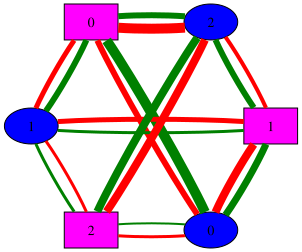

In [7]:
model.plot_graph(100, 200)

## Результаты моделирования

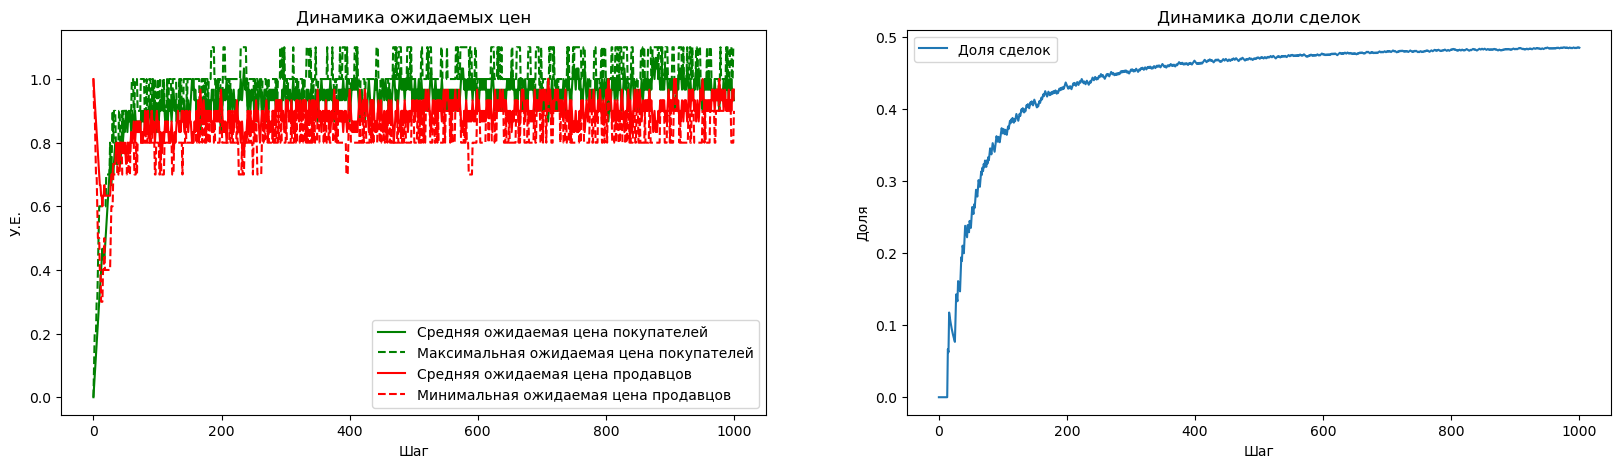

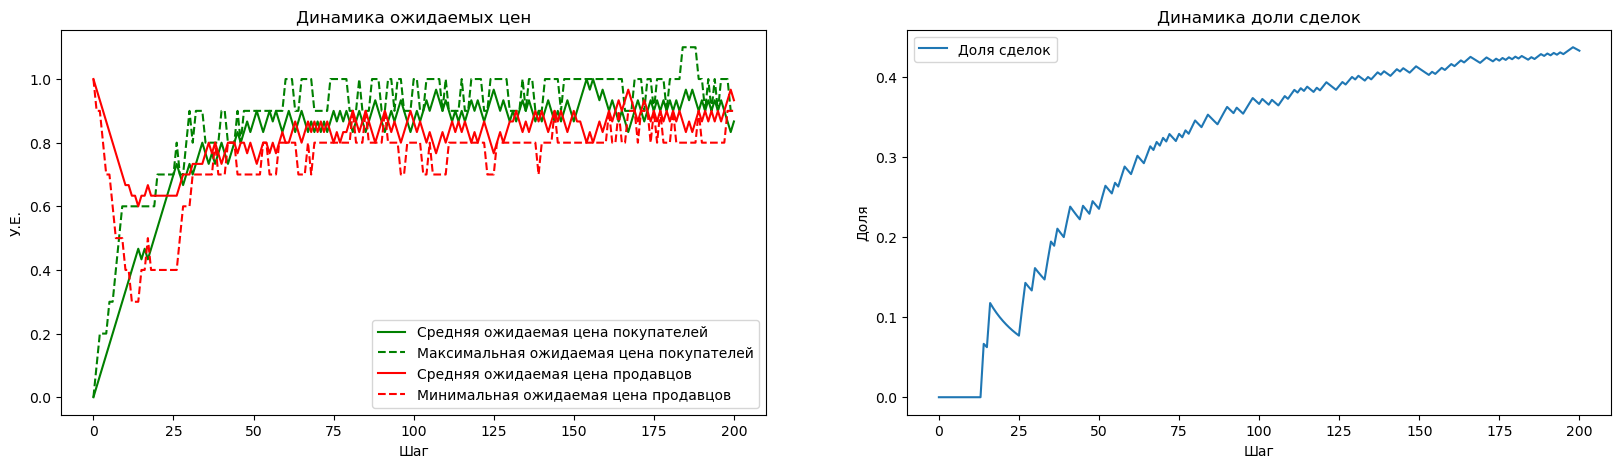

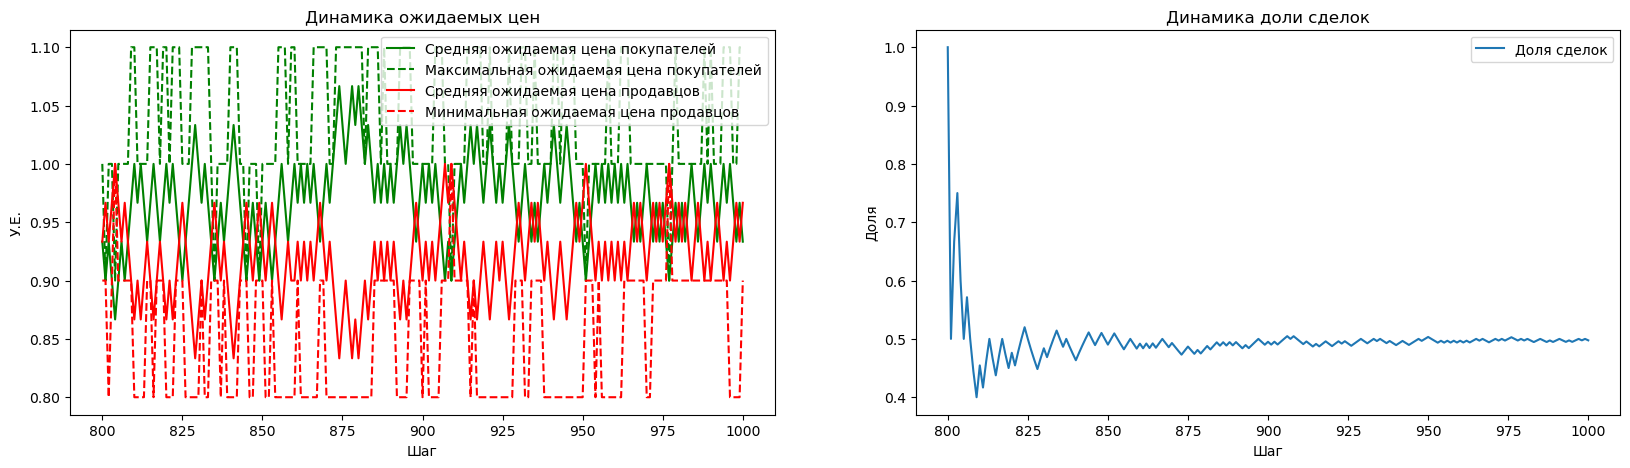

In [8]:
model.plot_dynamics(0, 1000)
model.plot_dynamics(0, 200)
model.plot_dynamics(800, 1000)

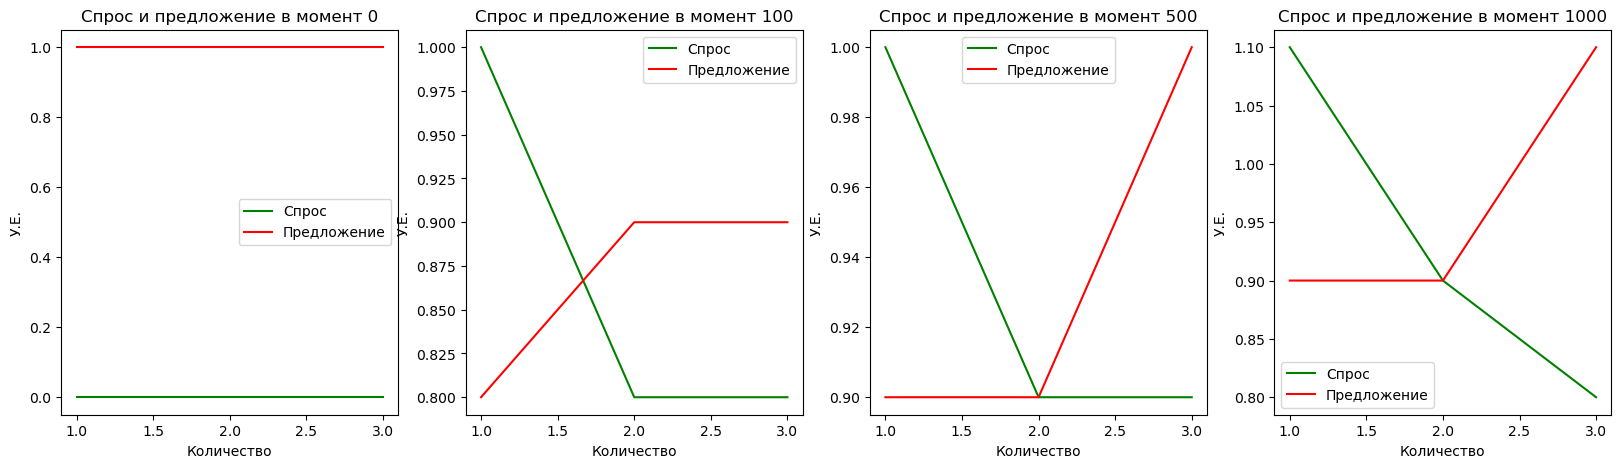

In [9]:
model.plot_supply_and_demand([0, 100, 500, 1000])

# Задания

При выполнения всех заданий Вам необходимо писать текст (в Markdown ячейках), вызывать существующие фрагменты кода и писать собственный код. При реализации кода придерживайтесь объектно-ориентированного подхода. Обращаем Ваше внимание, что в данных заданиях будет в первую очередь будет оцениваться Ваши интерпретации и выводы относительно свойств и поведения моделей.   

## Задание 1 (1 балл)

Запустите базовую модель с разными параметрами. Проанализируйте, как меняется поведение модели в зависимости от изменения параметров. Опишите эти изменения.

Проинтерпретируйте (дайте объяснение) результаты работы базовой модели. В частности, обратите внимание на следующие аспекты:
* Ожидаемые цены попадают в некоторый интервал.
* Доля сделок выходит на некоторый постоянный уровень.
* Скорости сходимости зависят от количества продавцов и покупателей и шага цены.
* Опишите характеристики изменений диаграмм связей со временем.

100%|██████████| 1001/1001 [00:00<00:00, 116447.05it/s]


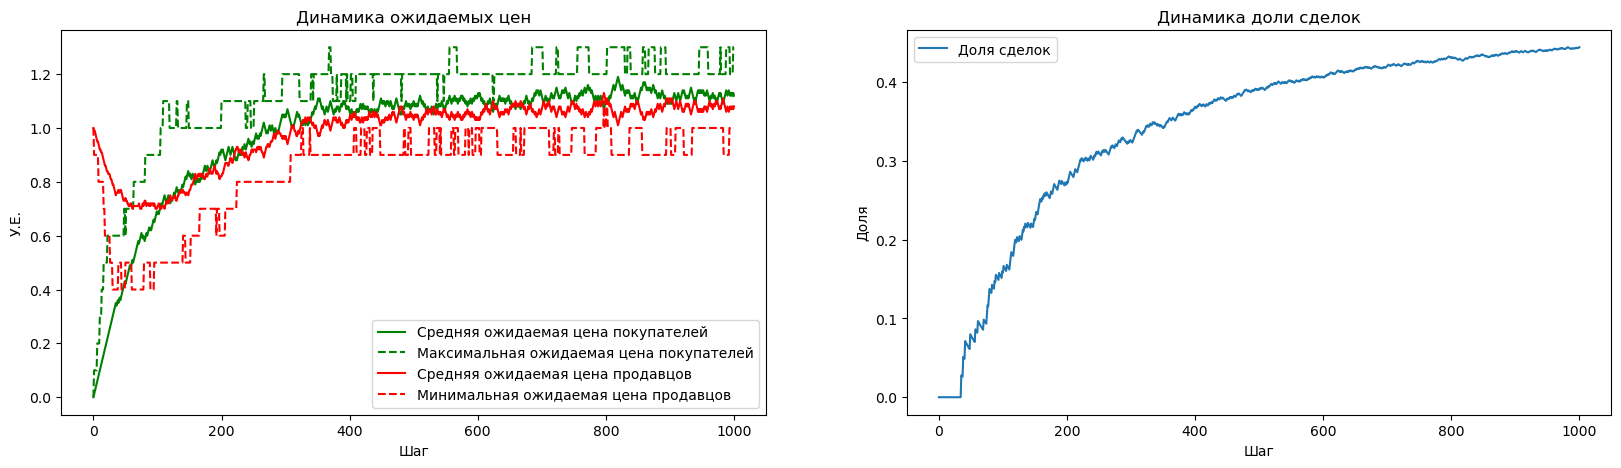

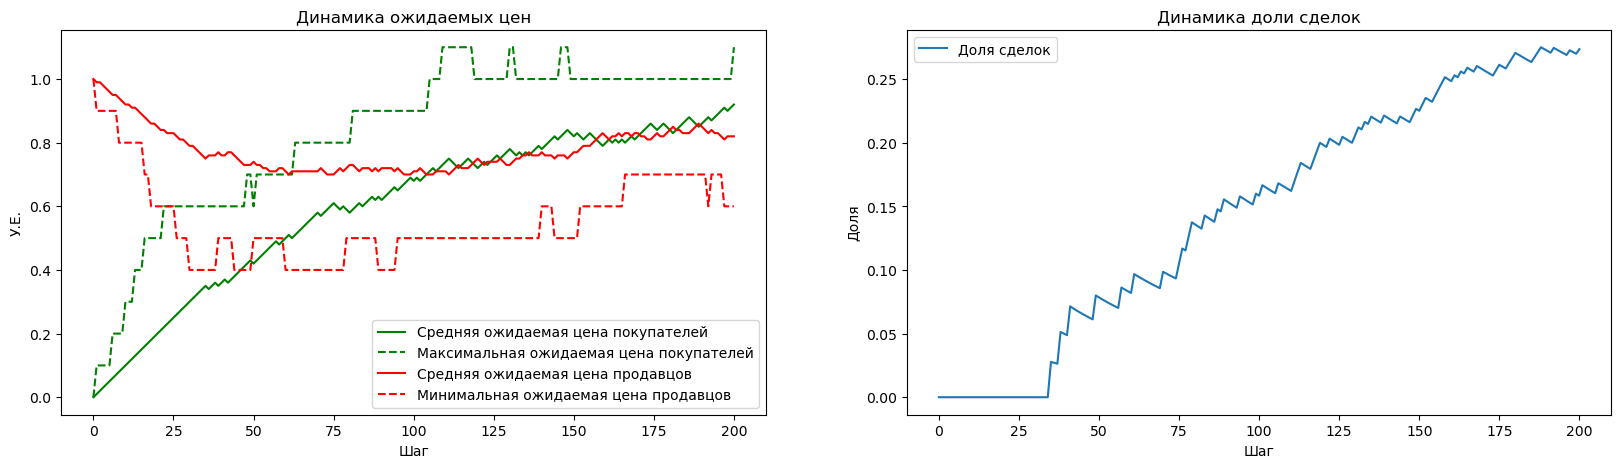

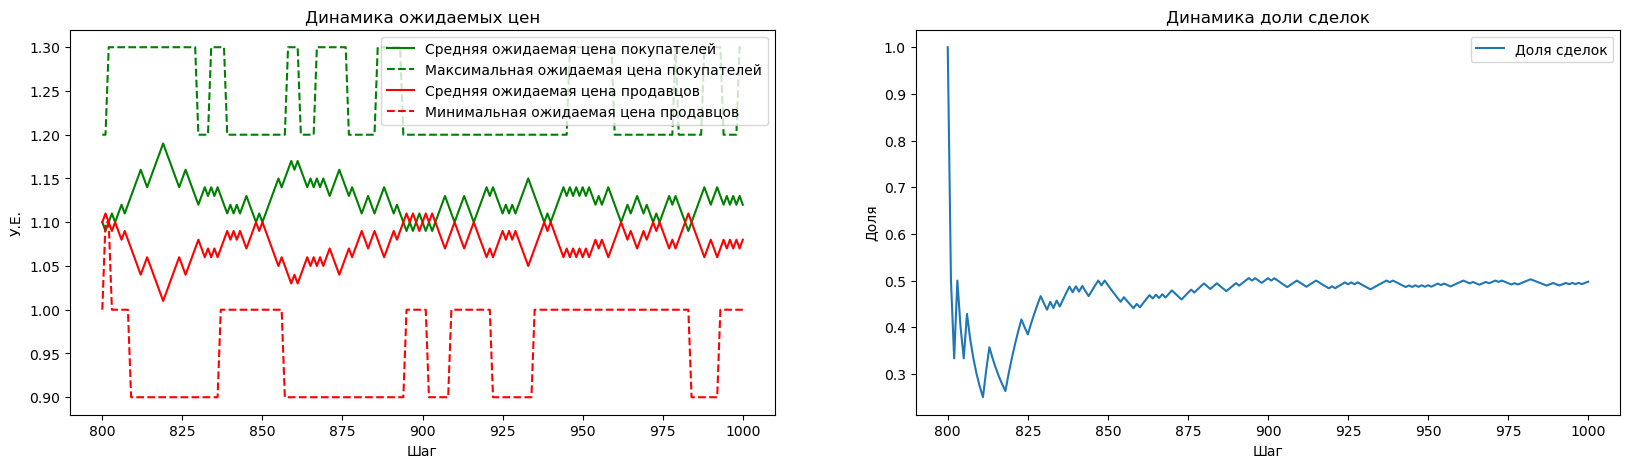

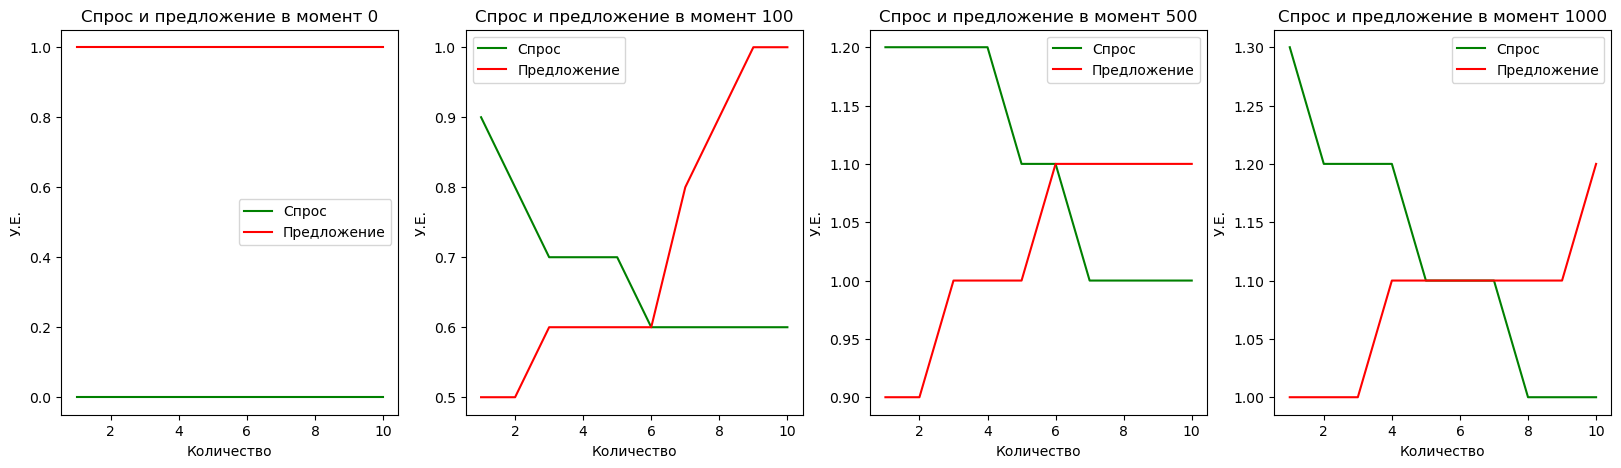

In [36]:
model_more_consumers_sellers = Model(num_of_consumers=10, 
                                     num_of_sellers=10,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_delta=0.1,
                                     seller_min=0,
                                     seller_max=1,
                                     seller_delta=0.1)

model_more_consumers_sellers.run(1000)

model_more_consumers_sellers.plot_dynamics(0, 1000)
model_more_consumers_sellers.plot_dynamics(0, 200)
model_more_consumers_sellers.plot_dynamics(800, 1000)
model_more_consumers_sellers.plot_supply_and_demand([0, 100, 500, 1000])

100%|██████████| 1001/1001 [00:00<00:00, 1770.27it/s]


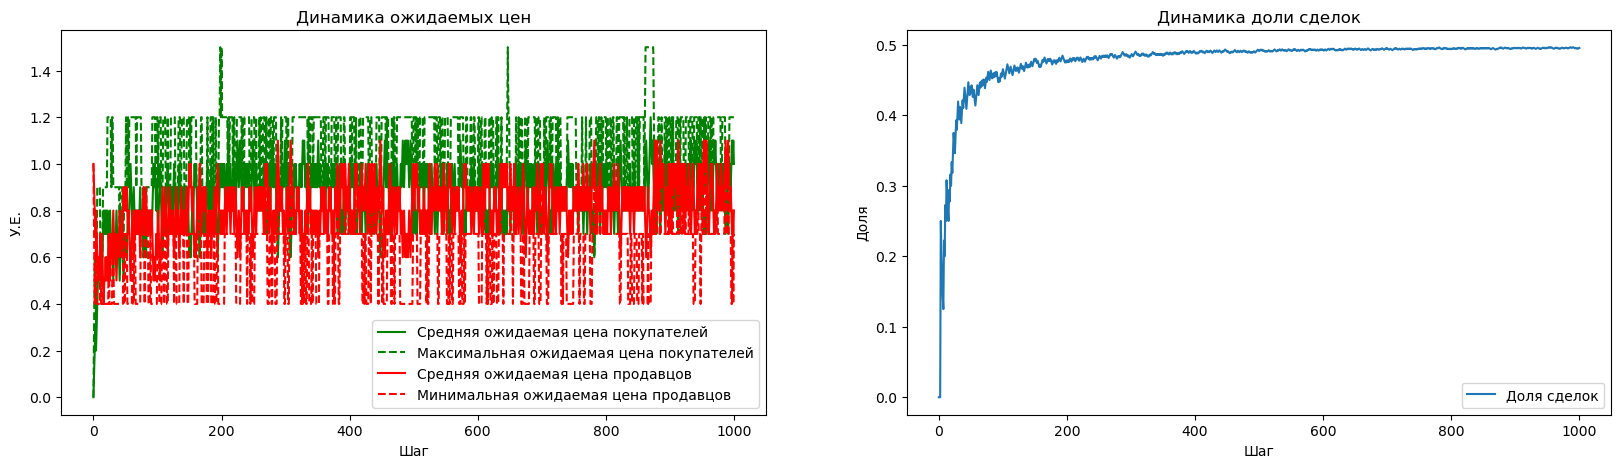

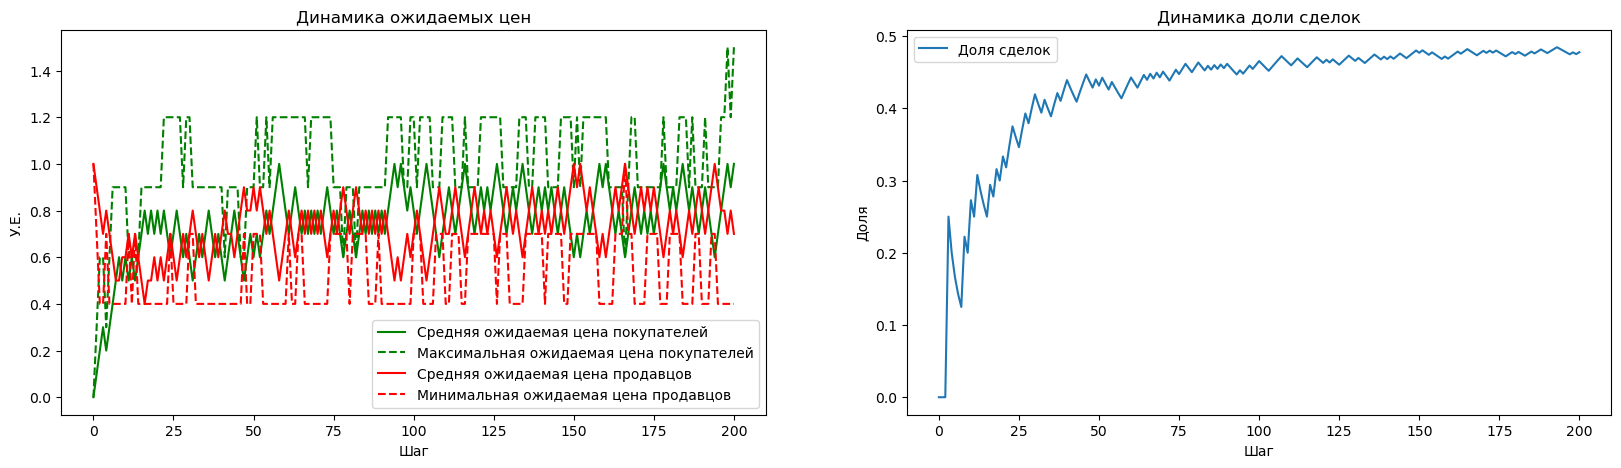

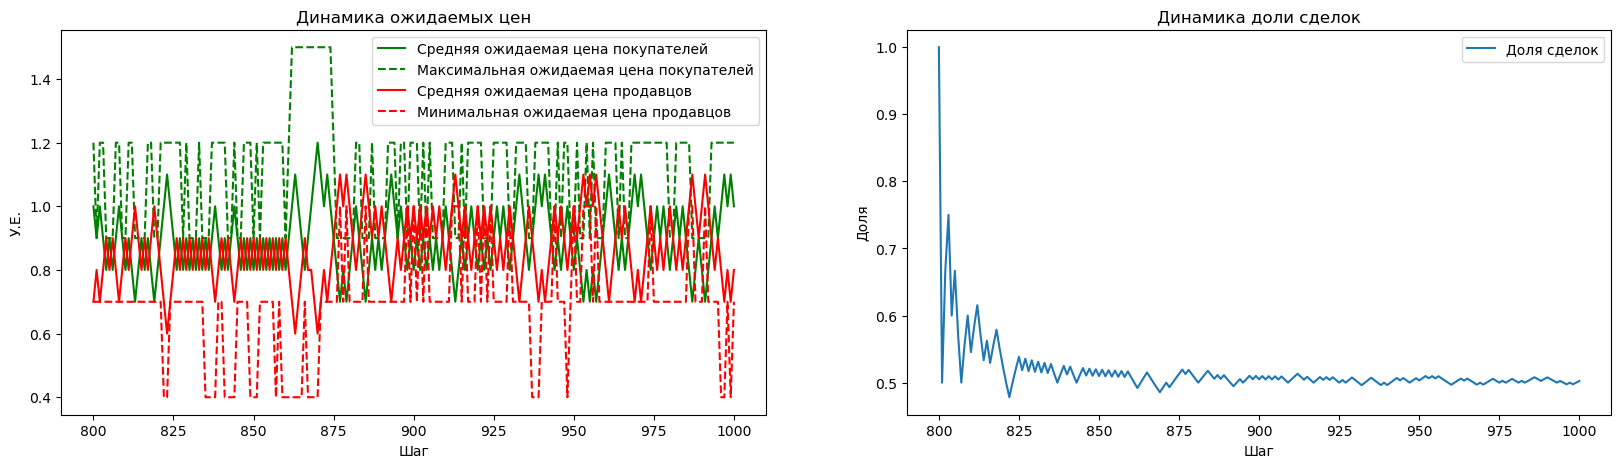

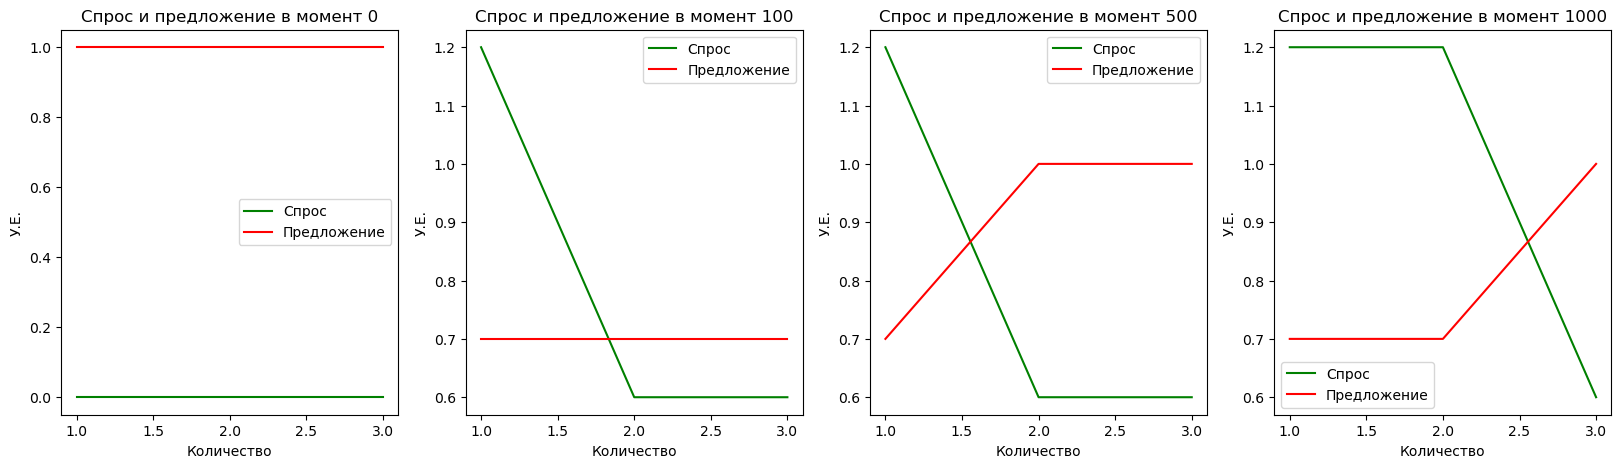

In [120]:
model_higher_delta = Model(num_of_consumers=3, 
                                     num_of_sellers=3,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_delta=0.3,
                                     seller_min=0,
                                     seller_max=1,
                                     seller_delta=0.3)

model_higher_delta.run(1000)

model_higher_delta.plot_dynamics(0, 1000)
model_higher_delta.plot_dynamics(0, 200)
model_higher_delta.plot_dynamics(800, 1000)
model_higher_delta.plot_supply_and_demand([0, 100, 500, 1000])

100%|██████████| 1001/1001 [00:00<00:00, 33166.38it/s]


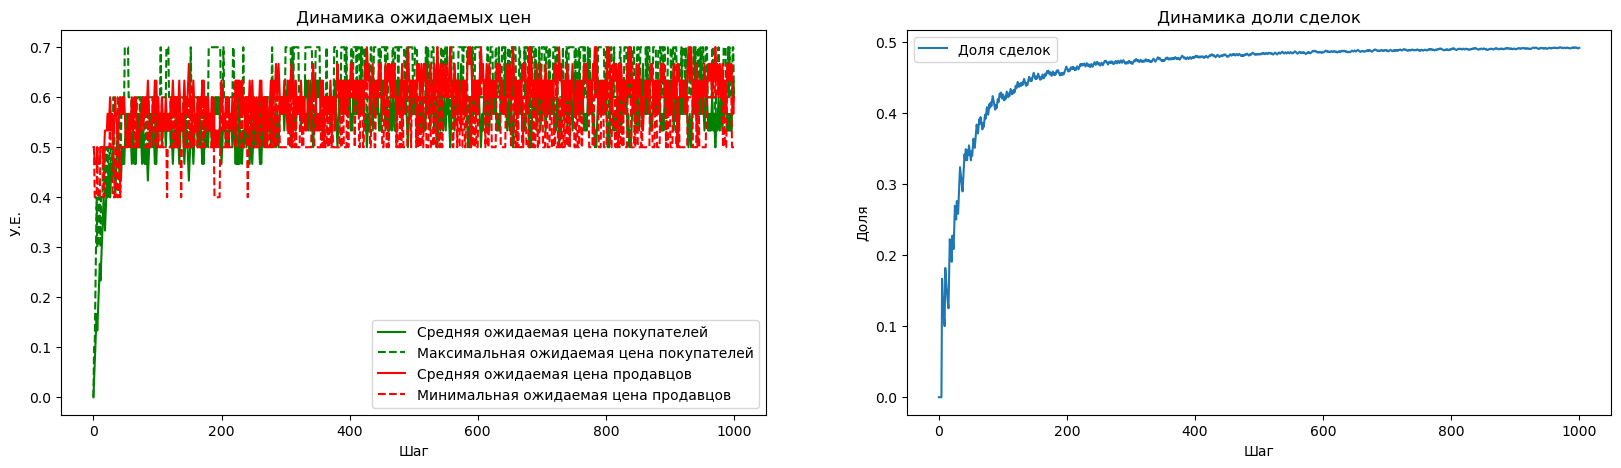

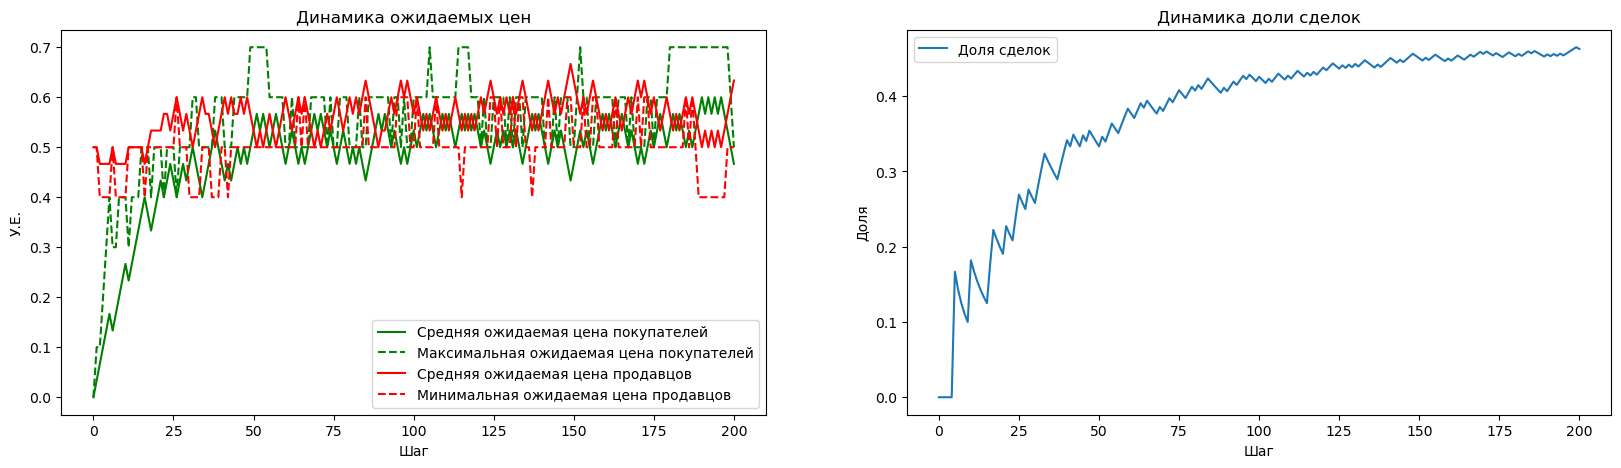

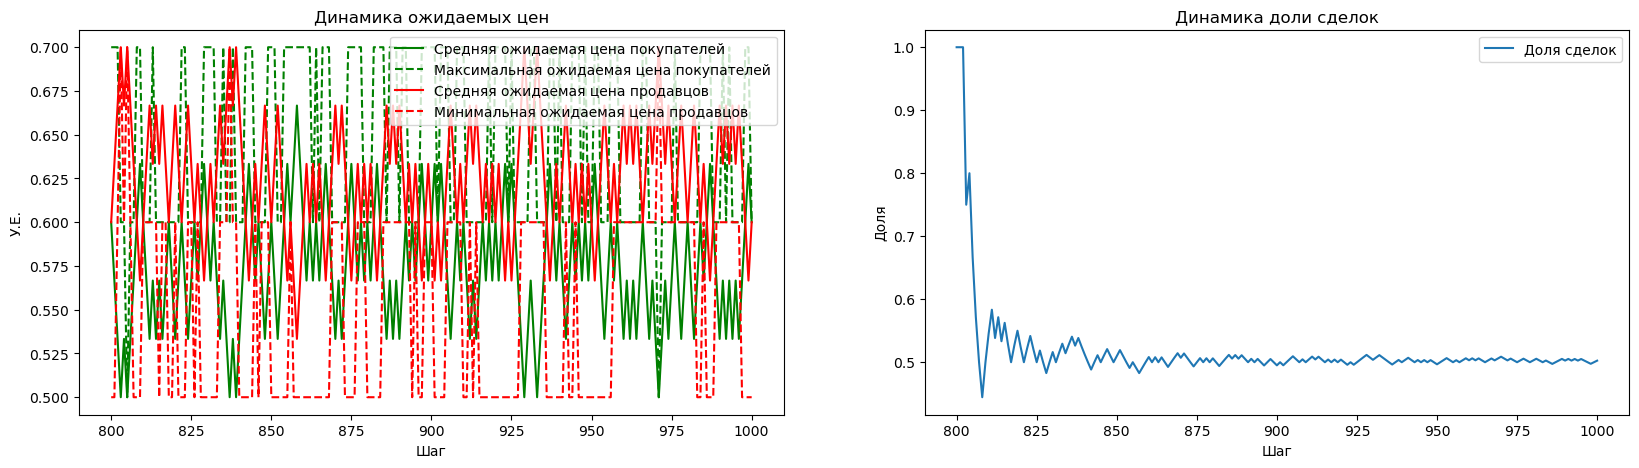

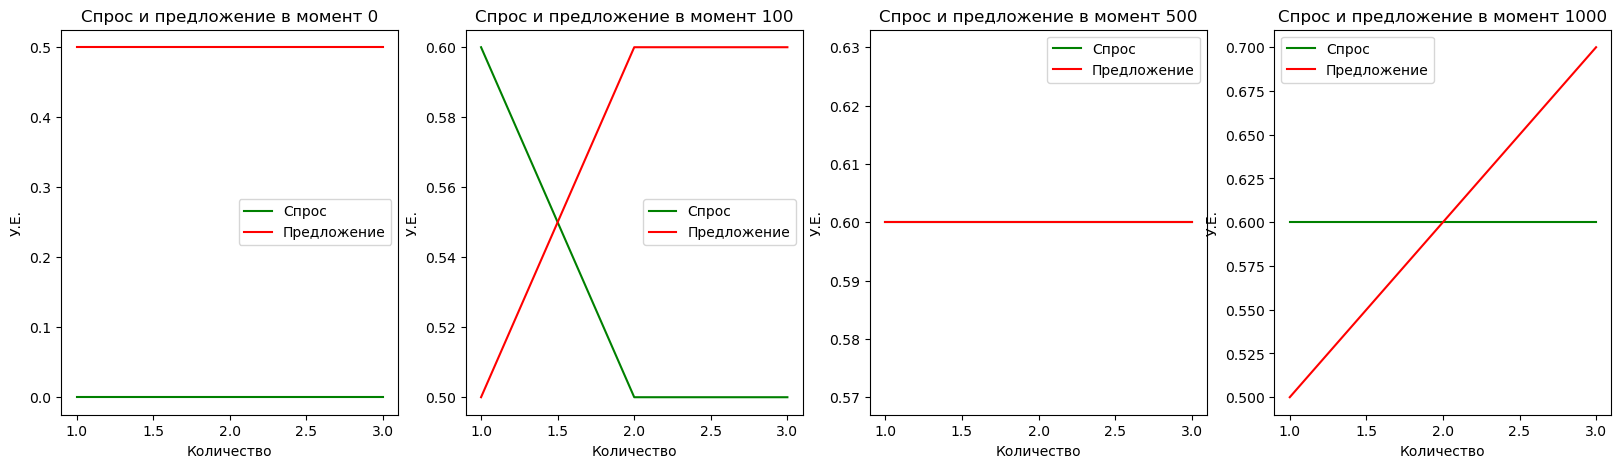

In [32]:
model_lower_prices_gap = Model(num_of_consumers=3, 
                                     num_of_sellers=3,
                                     consumer_min=3.2,
                                     consumer_max=3.5,
                                     consumer_delta=0.1,
                                     seller_min=0.25,
                                     seller_max=0.5,
                                     seller_delta=0.1)

model_lower_prices_gap.run(1000)
model_lower_prices_gap.plot_dynamics(0, 1000)
model_lower_prices_gap.plot_dynamics(0, 200)
model_lower_prices_gap.plot_dynamics(800, 1000)
model_lower_prices_gap.plot_supply_and_demand([0, 100, 500, 1000])

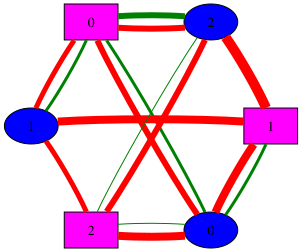

In [123]:
model.plot_graph(0, 50)

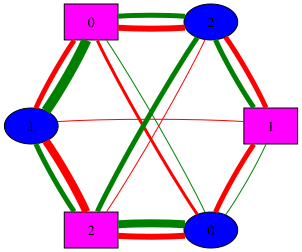

In [125]:
model.plot_graph(50, 100)

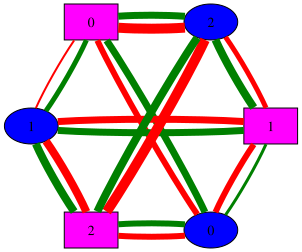

In [124]:
model.plot_graph(900, 1000)

* Изначально агенты-продавцы имеют достаточно высокий уровень ожидаемых цен, а агенты-покупатели - наоборот, низкий, из-за этого в первые такты моделей большинство сделок являются неудачными, однако, т.к. после каждой проваленной сделки продавцы опускают свои цены, а покупатели поднимают, то начиная с определенного момента графики средних ожидаемых цен производителей и потребителей начинают пересекаться, и цены начинают попадать в определенную окрестность, т.к. в силу случайной генерации пары покупателя и продавца, которые будут пытаться совершать сделку на каждом шаге, каждый отдельно взятый потребитель (соотв. продавец) не может слишком завышать(занижать) свою цену, т.к. после пересечения графиков средних цен покупателей и продавцов, всегда найдется агент, который покупает (соотв. продает) по ценне не ниже (не выше) средней, что и обеспечивает сходимость стоимости товара к рыночной. Как видно из запусков модели с разными параметрами, ожидаемые цены продавцов и покупателей сходятся с какого-то момента вне зависимости от количества продавцов и покупателей, их мин и макс цен, дельты их цен.

* По мере того как покупатели и продавцы выравнивают свои ожидания относительно цены товара, доля сделок выходит на постоянный уровень (удачными являются ~ 50% сделок), т.к. по мере выравния ожидания цен, агентам легче становится договориться о цене, что в силу попадания цен в определенных интервал гарантируют нам успешность примерно каждой второй сделки.  На волатильность этой характеристики также влияют параметры дельт, на которые агенты корректиркют свои ожидания от цены. Но при всех разумных параметрах дельт модель рано или поздно позволяет достичь равновесия спроса и предложения на рынке

* Скорость сходимости действительно зависит от количества агентов на рынке, как видно на запуске модели, чем больше количество агентов, тем медленнее сходимость цен, это можно объяснить тем что при большом количетсве альтернатив, индивиду сложнее сориентироваться на рынке и договориться о цене с конкретным продавцом, т.к. в условиях случайного состовления пар на сделку, в каждой конкретной сделке могут встретиться покупатель и продавец с полярно разными ожиданиями цены, что увеличивает скорость сходимости. Так же отметим, что при высокой дельте скорость сходимости быстрее, т.к. на начальных тактах модели, когда все сделки являются безуспешными, при большей дельте, агенты быстрее корректируют свои ожидания от цены, что позволяет им быстрее достичь рыночного равновесия. Однако высокая дельта также способствует большей волатильности цены, что вполне ожидаемо по построению модели.

* В силу причин, изложенных выше в графе связи в начальный момент времени почти все красные ребра имеют достачно большую ширину, т.к. агенты не могут договориться о цене и большинство сделок не состоятся. В следующие моменты времени, по мере того как покупатели и продавцы выравнивают ожидаемый уровень цен, начинают уплотняться зеленые ребра в графе, постепенно уровень удачных сделок выходит на отметку 50%, что можно видеть и на графе - плотность зеленых и красных ребер становится примерно равной. 



## Задание 2 (2 балла)


Модифицируйте базовую модель одним из указанных ниже вариантов. (2)

<b><font color="red">!</font> Номер Вашего варианта указан в <a href="https://docs.google.com/spreadsheets/d/1jWBLQ1bJG2t2Ci38r1xFrKP06VjFn-IyKQO4PIEvXTA/edit#gid=0">таблице</a>.</b>

1. Разные вероятности выбора разных продавцов и покупателей.
2. Генерация разных групп покупателей и продавцов.
3. Разные переговорные позиции продавцов и покупателей (в том числе случайные).
4. Ожидания покупателей и продавцов меняются только в сторону средней цены предыдущего периода.
5. К граничным ценам продавцов и покупателей каждый период добавляется случайная величина.

* Продемонстрируйте и опишите работу модифицированной модели.
* Проинтерпретируйте результаты работы модели.

In [38]:
class Group_of_consumers():
    def __init__(self, group_min_price, group_max_price, group_delta) -> None:
        self.min_price = group_min_price
        self.max_price = group_max_price
        self.delta = group_delta
    
    def add_consumer(self) -> Consumer:
        consumer = Consumer(self.min_price, self.max_price, self.delta)
        return consumer

class Group_of_sellers():
    def __init__(self, group_min_price, group_max_price, group_delta) -> None:
        self.min_price = group_min_price
        self.max_price = group_max_price
        self.delta = group_delta
    
    def add_seller(self) -> Seller:
        seller = Seller(self.min_price, self.max_price, self.delta)
        return seller

class Model_diffrent_groups(Model):
    def __init__(self, num_of_consumers, num_of_sellers, consumer_min, consumer_max, consumer_min_max_delta, consumer_delta, consumer_delta_delta, seller_min, seller_max, seller_min_max_delta, seller_delta, seller_delta_delta, num_of_consumer_groups, num_of_seller_groups):
        self.num_of_consumer_groups = num_of_consumer_groups
        self.num_of_seller_groups = num_of_seller_groups
        self.num_of_consumers = num_of_consumers
        self.num_of_sellers = num_of_sellers

        self.consumer_groups = []
        self.seller_groups = []

        #создаем различные группы
        for _ in range(num_of_consumer_groups):
            group_min_price = consumer_min - consumer_min_max_delta + 2 * random.random() * consumer_min_max_delta
            group_max_price = consumer_max - consumer_min_max_delta + 2 * random.random() * consumer_min_max_delta
            group_delta = consumer_delta - consumer_delta_delta + 2 * random.random() * consumer_delta_delta
            self.consumer_groups.append(Group_of_consumers(group_min_price, group_max_price, group_delta))
        
        for _ in range(num_of_seller_groups):
            group_min_price = seller_min - seller_min_max_delta + 2 * random.random() * seller_min_max_delta
            group_max_price = seller_max - seller_min_max_delta + 2 * random.random() * seller_min_max_delta
            group_delta = seller_delta - seller_delta_delta + 2 * random.random() * seller_delta_delta
            self.seller_groups.append(Group_of_sellers(group_min_price, group_max_price, group_delta))


        # Список всех продавцов модели
        self.consumers = []
        for _ in range(num_of_consumers):
            #каждому покупателю присваиваем случайную группу
            group_id = random.randint(0, num_of_consumer_groups - 1)
            self.consumers.append(self.consumer_groups[group_id].add_consumer())
        
        # Список всех покупателей модели
        self.sellers = []
        for _ in range(num_of_sellers):
            #каждому продавцу присваиваем случайную группу
            group_id = random.randint(0, num_of_seller_groups - 1)
            self.sellers.append(self.seller_groups[group_id].add_seller())

        # Список списков. На позиции i находится список текущих значений expect_price для всех покупателей на шаге i.
        self.consumers_expect_price = []

        # Список списков. На позиции i находится список текущих значений expect_price для всех продавцов на шаге i.
        self.sellers_expect_price = []

        # Список результатов сделок. На позиции i находится словарь вида
        # {
        #     'consumer_id' : consumer_id,
        #     'seller_id' : seller_id
        #     'result' : result
        # }
        # где result = 1, если на i шаге была успешная сделка, иначе 0.
        self.deals_results = []        

Введеем новые параметры модели - количество групп продавцов и потребителей и параметры, показываюшие насколько сильно могут отличаться минимальные и максимальные цены и дельта цен в разных группах. Теперь при создании модели создаем группы потребителей и продавцов - параметры мин макс цены и дельты в каждой группе определяются рандомно, внутри определенного диапазона, при создании агента, ему случайно будет присваиваться одна из существующих групп. Запустим модель.

100%|██████████| 3001/3001 [00:00<00:00, 56590.59it/s]

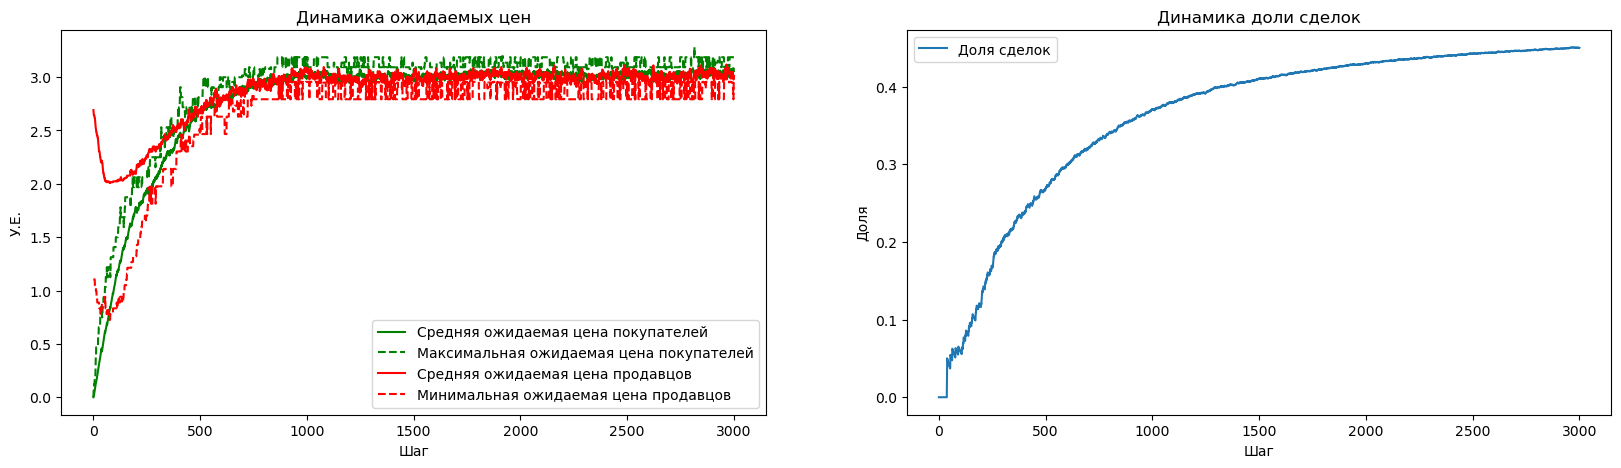

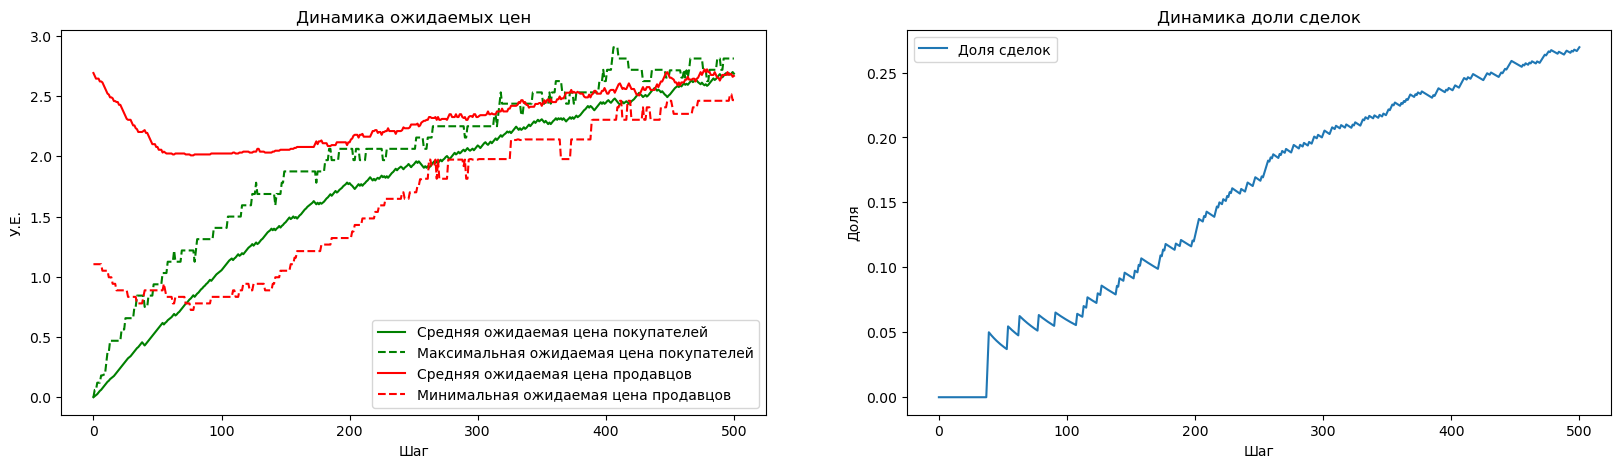

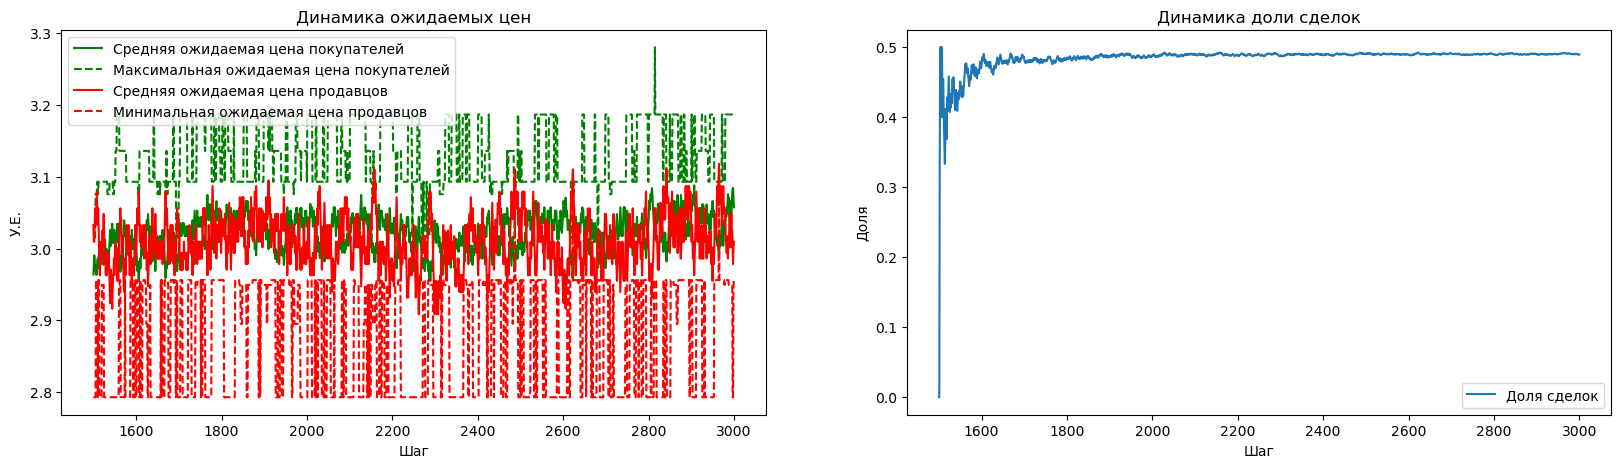

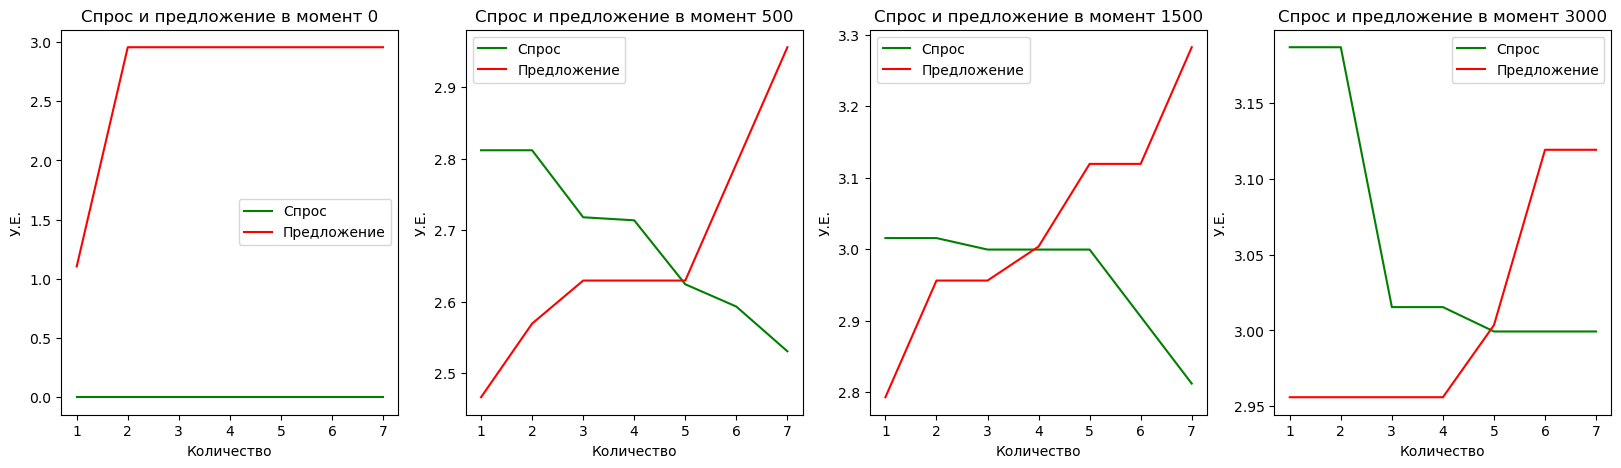

In [47]:
model_with_groups = Model_diffrent_groups(num_of_consumers=7, 
                                     num_of_sellers=7,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_min_max_delta=2,
                                     consumer_delta=0.1,
                                     consumer_delta_delta=0.07,
                                     seller_min=1,
                                     seller_max=2,
                                     seller_min_max_delta=1,
                                     seller_delta=0.1,
                                     seller_delta_delta=0.07,
                                     num_of_consumer_groups=2,
                                     num_of_seller_groups=2)

model_with_groups.run(3000)
model_with_groups.plot_dynamics(0, 3000)
model_with_groups.plot_dynamics(0, 500)
model_with_groups.plot_dynamics(1500, 3000)
model_with_groups.plot_supply_and_demand([0, 500, 1500, 3000])

Обратим внимание на то, что по сравнению с базовой моделью достаточно сильно снизилась скорость сходимости, это можно объяснить тем, что теперь агенты могут являться представителями различных групп, которые изначально имеют совершенно разные ожидания от цены товара на рынке. Также измениась динамика цен по сравнению с базовой моделью, теперь цены колеблятся в более широком диапазоне, это также объясняется тем, что у разных групп может быть совершенно не похожий друг на друга шаг цены, благодоря чему агенты из разных групп могут сильнее влиять на рыночную стоимость товара. При этом снизилась также общая доля удачных сделок, т.к. для каждой сделки пара агентво выбираются случайным образом, то в модфицированной модели велика вероятность того, что в конкретной сделке покупатель и продавец относятся к группам агентов, обладающих разными ожиданиями от цены, что снижает вероятность успеха сделки

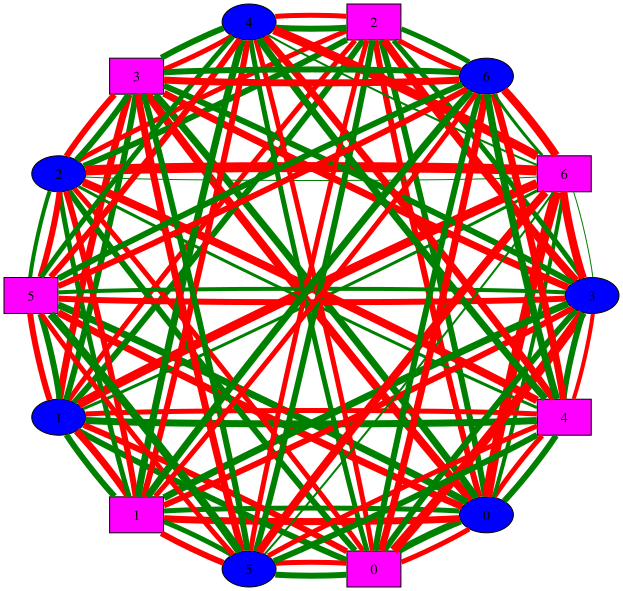

In [46]:
model_with_groups.plot_graph(0, 3000)

Также отличия базовой и модифицированной моделей можно заметить на графе. Если раньше между каждыми двумя агентами зеленые и красные ребра были примерно одиннаковой ширины, то теперь мы можем наблюдать, что существуют агенты с очень толстым красным ребром и тонким зеленым(например покупатель 2 и продавец 6 на этом запуске) и наоборот. Это объсняется тем, что покупатели из одной группы более склонны выбирать продавцов из группы, для которой их ожидания по цене наиболее близки (т.е. например, покупатель из группы А будет чаще совершать удачные сделки с продавцом из группы 1, чем с продавцом из группы 2, т.к. у продавца из группы 2 слишком высокая цена для покупателей из группы А) Это свойство модели хорошо соотносится с реальными рынками, где производители тоже зачастую работают на определенную целевую аудиторию

100%|██████████| 3001/3001 [00:00<00:00, 439125.95it/s]


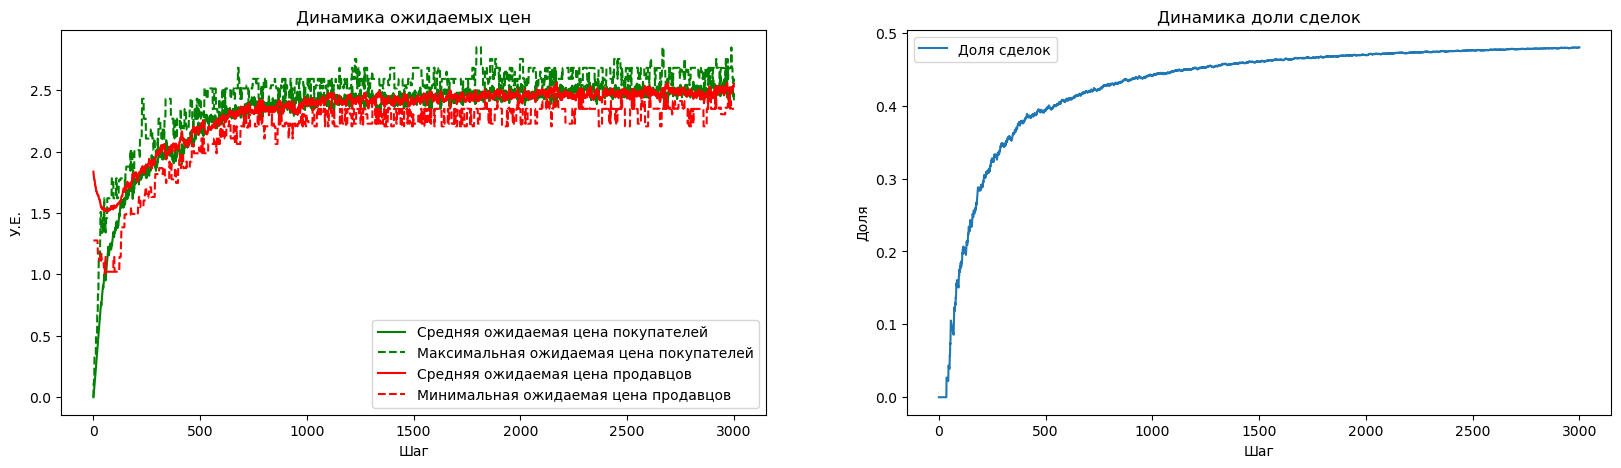

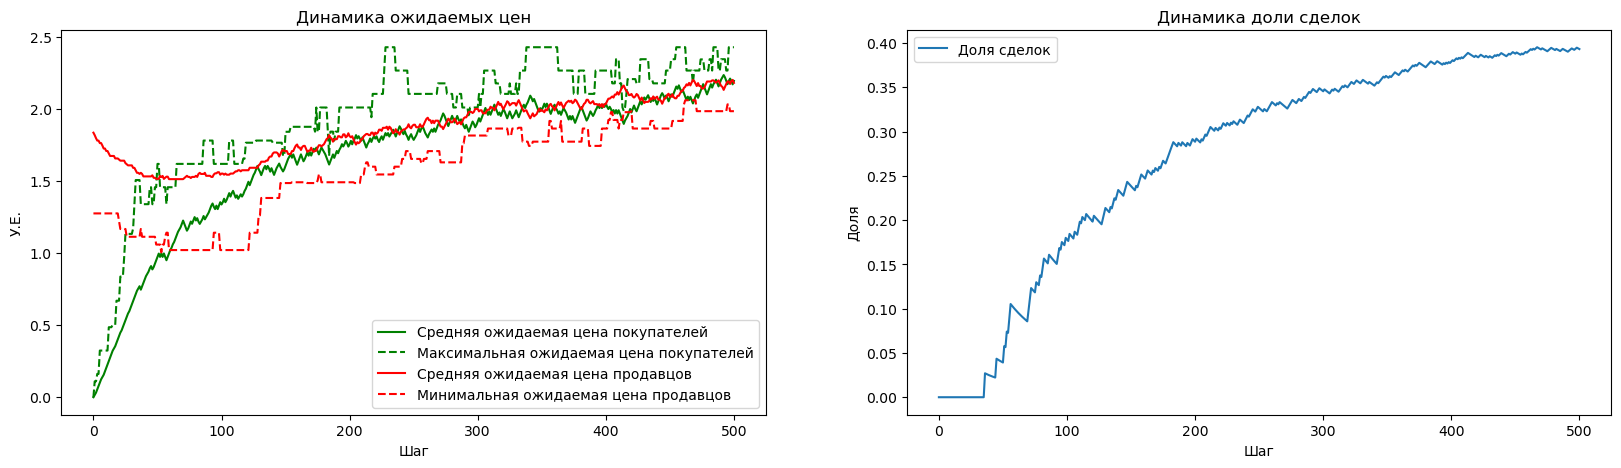

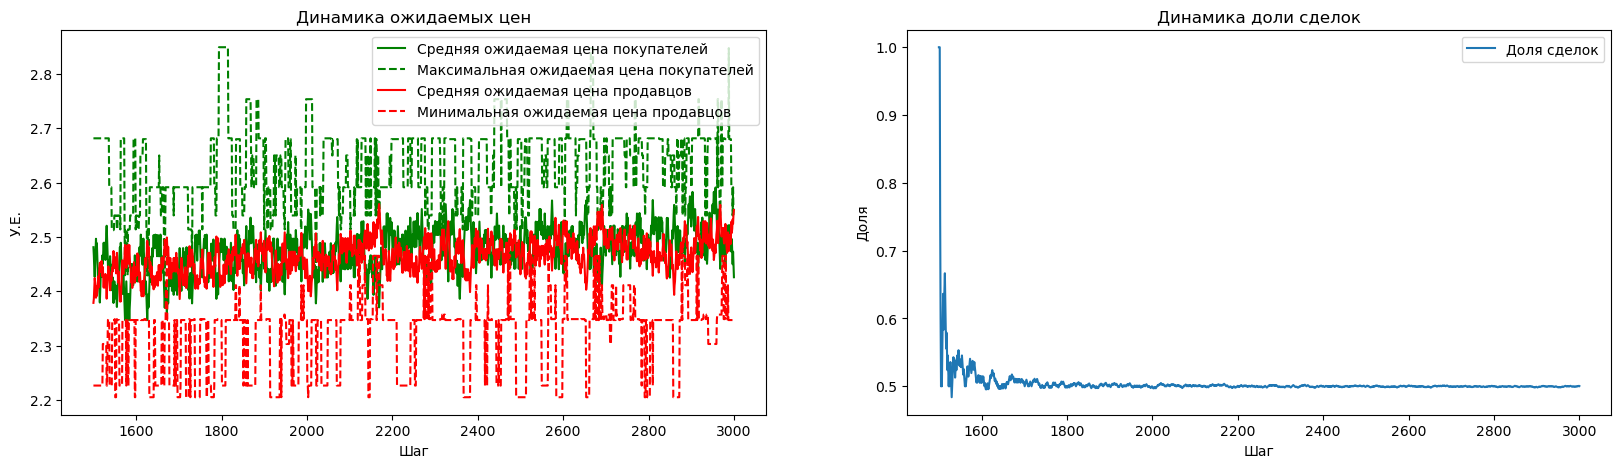

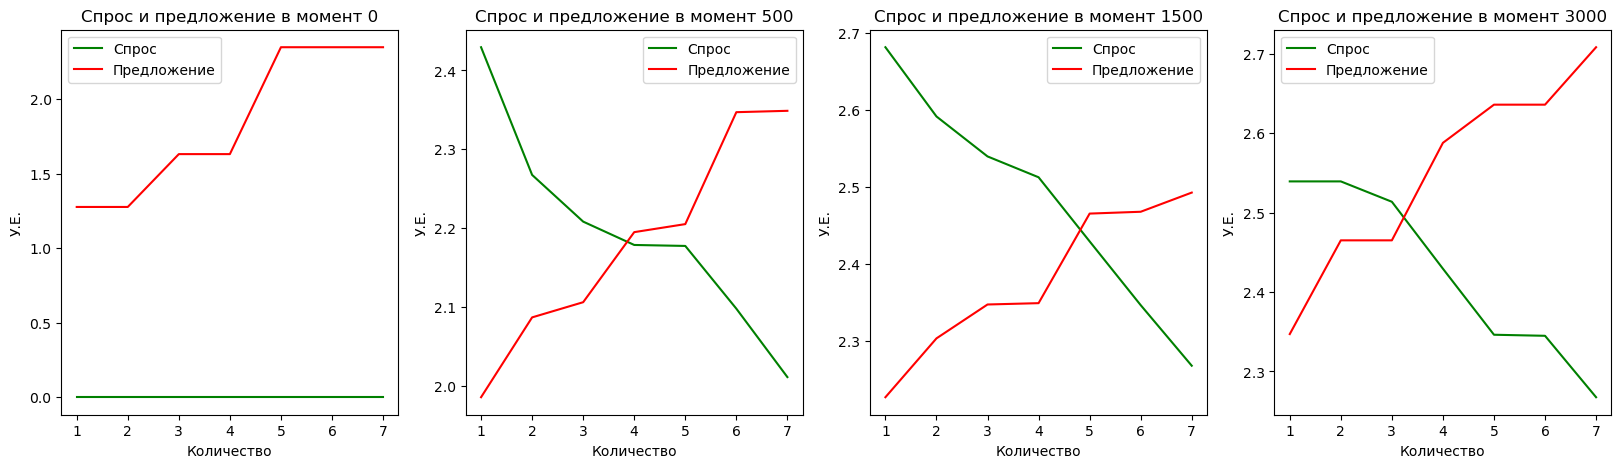

In [136]:
model_with_groups2 = Model_diffrent_groups(num_of_consumers=7, 
                                     num_of_sellers=7,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_min_max_delta=2,
                                     consumer_delta=0.1,
                                     consumer_delta_delta=0.07,
                                     seller_min=1,
                                     seller_max=2,
                                     seller_min_max_delta=1,
                                     seller_delta=0.1,
                                     seller_delta_delta=0.07,
                                     num_of_consumer_groups=5,
                                     num_of_seller_groups=5)

model_with_groups2.run(3000)
model_with_groups2.plot_dynamics(0, 3000)
model_with_groups2.plot_dynamics(0, 500)
model_with_groups2.plot_dynamics(1500, 3000)
model_with_groups2.plot_supply_and_demand([0, 500, 1500, 3000])

Добавим больше групп, видим, что скорость сходимости немного улучшилась, но она все еще ниже, чем у базовой модели. Это связано с тем, что при большом количестве групп не так важны различия между двумя конкретными группами (поэтому маловероятно, что одна группа будет тянуть цену вниз, а другая вверх) Все остальные выводы остаются валидными

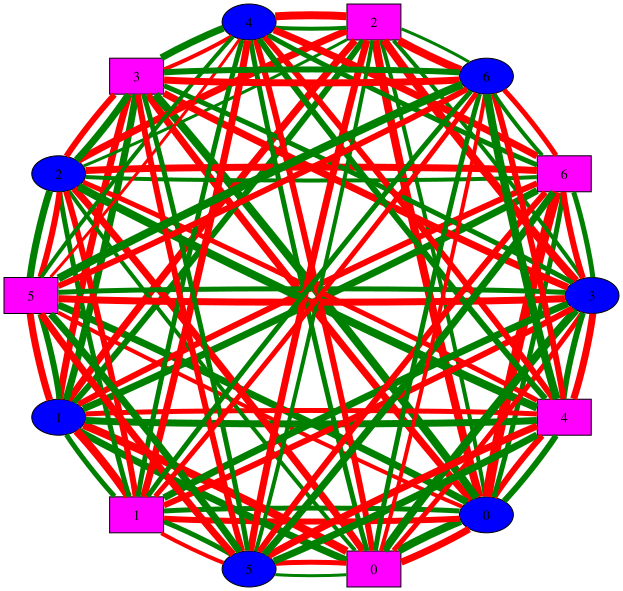

In [137]:
model_with_groups2.plot_graph(0, 3000)

## Задание 3 (3 балла)

Предположим, что теперь мы рассматриваем последовательные дни, и контакты продавцов и покупателей происходят в течение дня. Количество контактов между продавцами и покупателями в день ограничено константой max_connections, и не меняется в процессе моделирования.

Выделим локальные (внутридневные) параметры, которые меняются и учитываются в течение одного дня. Но на следующий день сбрасываются до исходных значений.

Модифицируйте базовую модель одним из указанных ниже вариантов. (1)

<b><font color="red">!</font> Номер Вашего варианта указан в <a href="https://docs.google.com/spreadsheets/d/1jWBLQ1bJG2t2Ci38r1xFrKP06VjFn-IyKQO4PIEvXTA/edit#gid=0">таблице</a>.</b>

1. Локальные параметры: количество сделок агента. Не может быть более одной сделки.
2. Локальные параметры: у каждого продавца свое фиксированное количество товара, которое он может продать в один день. В конце для излишки сгорают.
3. Локальные параметры: у каждого покупателя свое фиксированное количество товара, которое он может купить в один день.
4. Локальные параметры: у каждого продавца случайное количество товара, которое он может продать в один день. В конце для излишки сгорают.
5. Локальные параметры: у каждого покупателя случайное количество товара, которое он может купить в один день.

* Продемонстрируйте и опишите работу модифицированной модели.
* Проинтерпретируйте результаты работы модели.

In [27]:
class Consumer_with_limits(Consumer):
    def __init__(self, consumer_min, consumer_max, consumer_delta):
        super().__init__(consumer_min, consumer_max, consumer_delta)
        self.had_deal = False
    
class Seller_with_limits(Seller):
    def __init__(self, seller_min, seller_max, seller_delta):
        super().__init__(seller_min, seller_max, seller_delta)
        self.had_deal = False

class Model_daily_limits(Model):
    def __init__(self, num_of_consumers, num_of_sellers, consumer_min, consumer_max, consumer_delta, seller_min, seller_max, seller_delta, max_connections):
        self.num_of_consumers = num_of_consumers
        self.num_of_sellers = num_of_sellers

        # Список всех продавцов модели
        self.consumers = [Consumer_with_limits(consumer_min, consumer_max, consumer_delta) for _ in range(num_of_consumers)]

        # Список всех покупателей модели
        self.sellers = [Seller_with_limits(seller_min, seller_max, seller_delta) for _ in range(num_of_sellers)]

        # Список списков. На позиции i находится список текущих значений expect_price для всех покупателей на шаге i.
        self.consumers_expect_price = []

        # Список списков. На позиции i находится список текущих значений expect_price для всех продавцов на шаге i.
        self.sellers_expect_price = []

        # Список результатов сделок. На позиции i находится словарь вида
        # {
        #     'consumer_id' : consumer_id,
        #     'seller_id' : seller_id
        #     'result' : result
        # }
        # где result = 1, если на i шаге была успешная сделка, иначе 0.
        self.deals_results = []        
        self.max_connections = max_connections
        self.current_connections = 0
    
    def deal(self, consumer_id, seller_id):
        '''
            Моделирование сделки между покупателем с индексом consumer_id и продавцом с индексом seller_id

            consumer_id -- индекс покупателя в массиве self.consumers
            seller_id -- индекс продавца в массиве self.sellers
        '''

        # Сохраняем текущие значения expect_price покупателей
        self.consumers_expect_price.append([consumer.expect_price for consumer in self.consumers])

        # Сохраняем текущие значения expect_price продавцов
        self.sellers_expect_price.append([seller.expect_price for seller in self.sellers])

        #проверяем дополнительно не было ли сделок сегодня
        if self.sellers[seller_id].expect_price <= self.consumers[consumer_id].expect_price and (not (self.sellers[seller_id].had_deal or self.consumers[consumer_id].had_deal)):
            # Сделка состоялась

            # Записываем факт состоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 1
                })

            # Данный покупатель решает уменьшить у себя expect_price и ставим маркер что у агента состоялась сделка
            self.consumers[consumer_id].decrease_expect_price()
            self.consumers[consumer_id].had_deal = True

            # Данный продавец решает увеличить у себя expect_price и ставим маркер что у агента состоялась сделка
            self.sellers[seller_id].increase_expect_price()
            self.sellers[seller_id].had_deal = True

        else:
            # Сделка не состоялась

            # Записываем факт несостоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 0
                })
            #если сделка сорвалась по ценовой причине 
            if not (self.sellers[seller_id].had_deal or self.consumers[consumer_id].had_deal):
                # Данный покупатель решает увеличить у себя expect_price
                self.sellers[seller_id].decrease_expect_price()

                # Данный продавец решает уменьшить у себя expect_price
                self.consumers[consumer_id].increase_expect_price()
        
    def run(self, num_of_steps):
        '''
            Запуск num_of_steps шагов модели
        '''
        for _ in trange(num_of_steps+1): # trange вместо range для визуализации прогресс-бара

            # Выбираем индекс покупателя случайным образом
            consumer_id = random.randrange(0, self.num_of_consumers)

            # Выбираем индекс продавца случайным образом
            seller_id = random.randrange(0, self.num_of_sellers)

            # Моделируем сделку
            self.deal(consumer_id, seller_id)
            self.current_connections += 1
            
            #проверяем не ли наступает новый день
            if (self.current_connections == self.max_connections):
                for i in range(self.num_of_sellers):
                    self.sellers[i].had_deal = False
                for i in range(self.num_of_consumers):
                    self.consumers[i].had_deal = False
                self.current_connections = 0

Добавим для каждого агента маркер была ли у него сделка в этот день или нет, теперь внутри сделки будем проверять, что у обоих агентов не было сделок в этот день. Также в модель добавим счетчик тактов, после каждой попытки сделки будем обновлять его и отслеживать момент наступления нового дня, тогда обнулим счетчик и маркеры у агентов. Запускаем модель.

100%|██████████| 1001/1001 [00:00<00:00, 263493.05it/s]


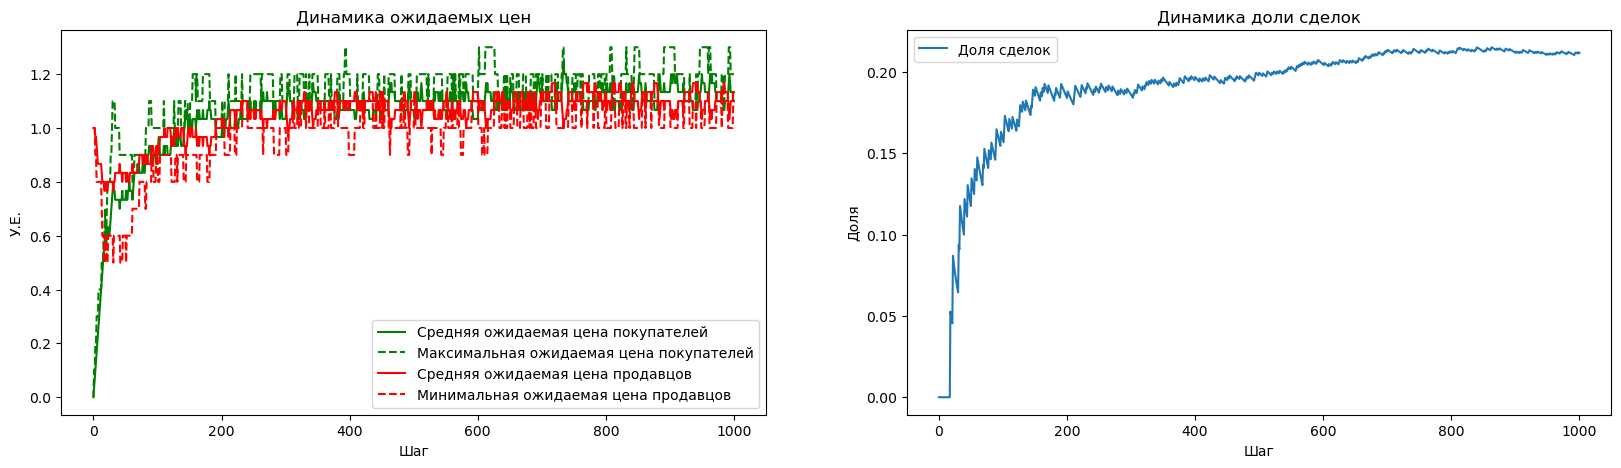

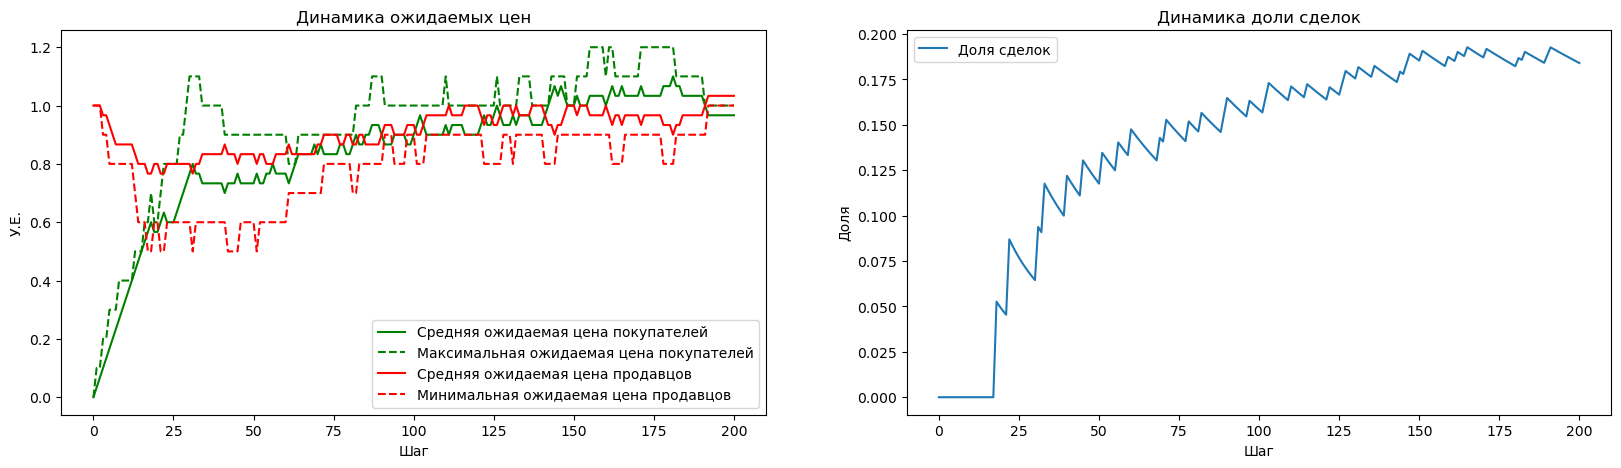

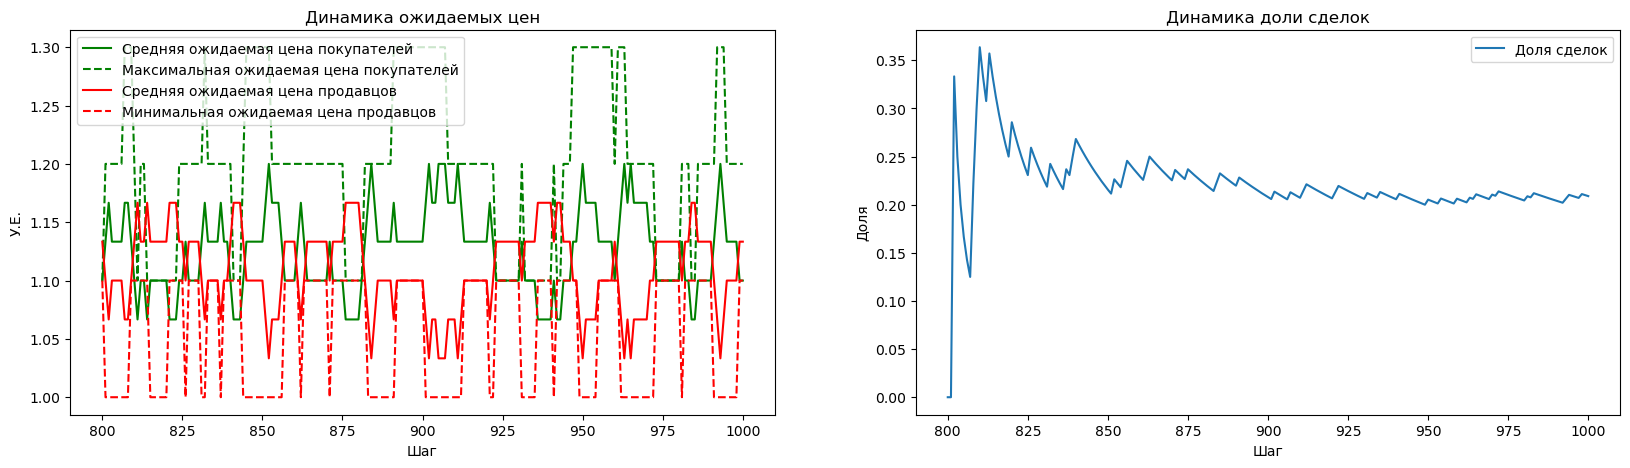

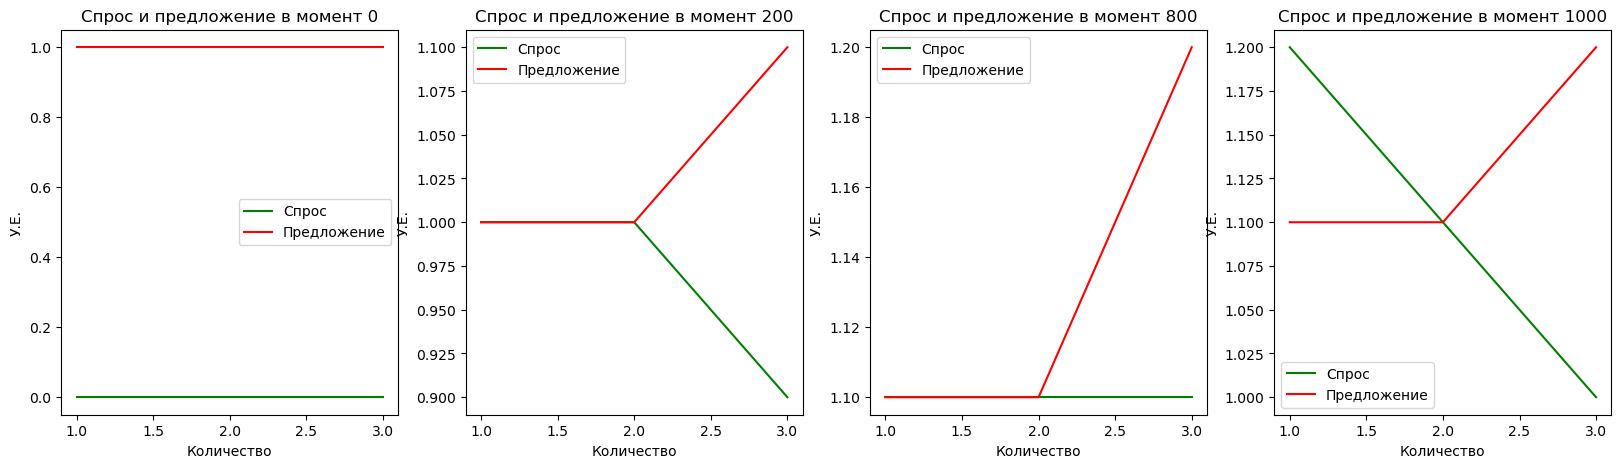

In [127]:
model_with_limits1 = Model_daily_limits(num_of_consumers=3, 
                                     num_of_sellers=3,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_delta=0.1,
                                     seller_min=0,
                                     seller_max=1,
                                     seller_delta=0.1,
                                     max_connections=10)

model_with_limits1.run(1000)
model_with_limits1.plot_dynamics(0, 1000)
model_with_limits1.plot_dynamics(0, 200)
model_with_limits1.plot_dynamics(800, 1000)
model_with_limits1.plot_supply_and_demand([0, 200, 800, 1000])

При небольшом количестве агентов и относительно длинной продолжительности дня получаем следующие результаты: заметно снизилась общая доля успешных сделок, это объясняется тем, что при выравнивании ожидаемых цен продавцов и покупателей, примерно каждая вторая сделка в обычных условиях является успешной, теперь же все продавцы и покупатели совершают по одной успешной сделке за день и все остальные сделки в рамках этого дня с их участием обречены на провал, это также заметно по характерным заломам на графике доли успешных сделок, а также по периодам, когда на графике динамике цен, эти самые цены являюстя горизонтальными прямыим, чего, очевидно, не могло бы быть в обычных условиях 

100%|██████████| 2001/2001 [00:00<00:00, 128556.37it/s]


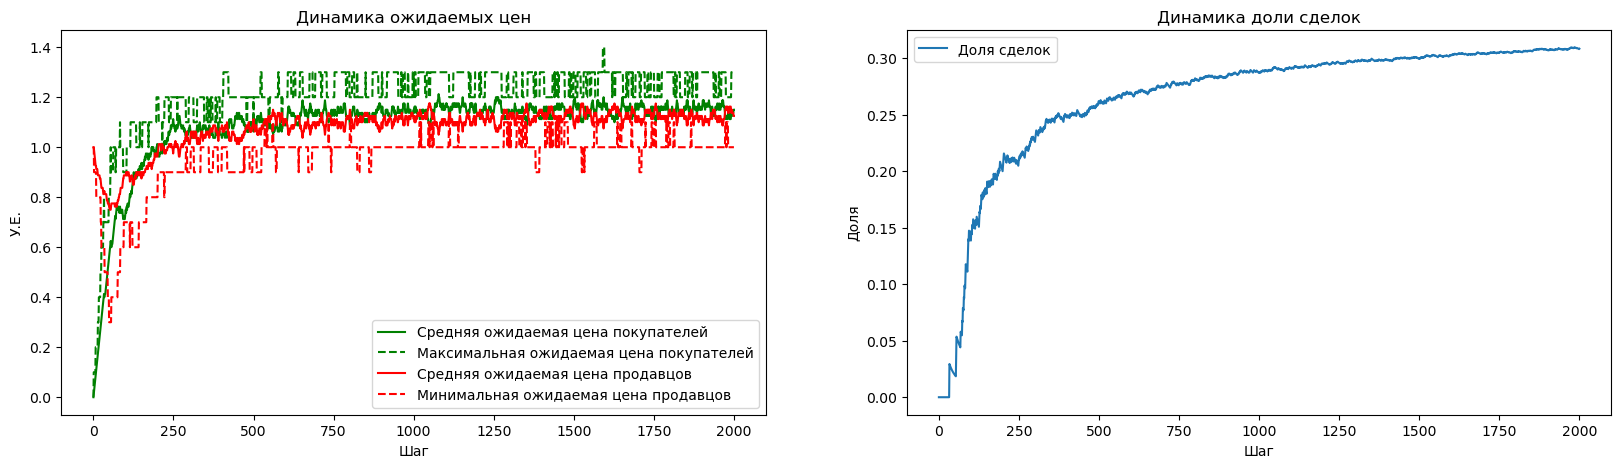

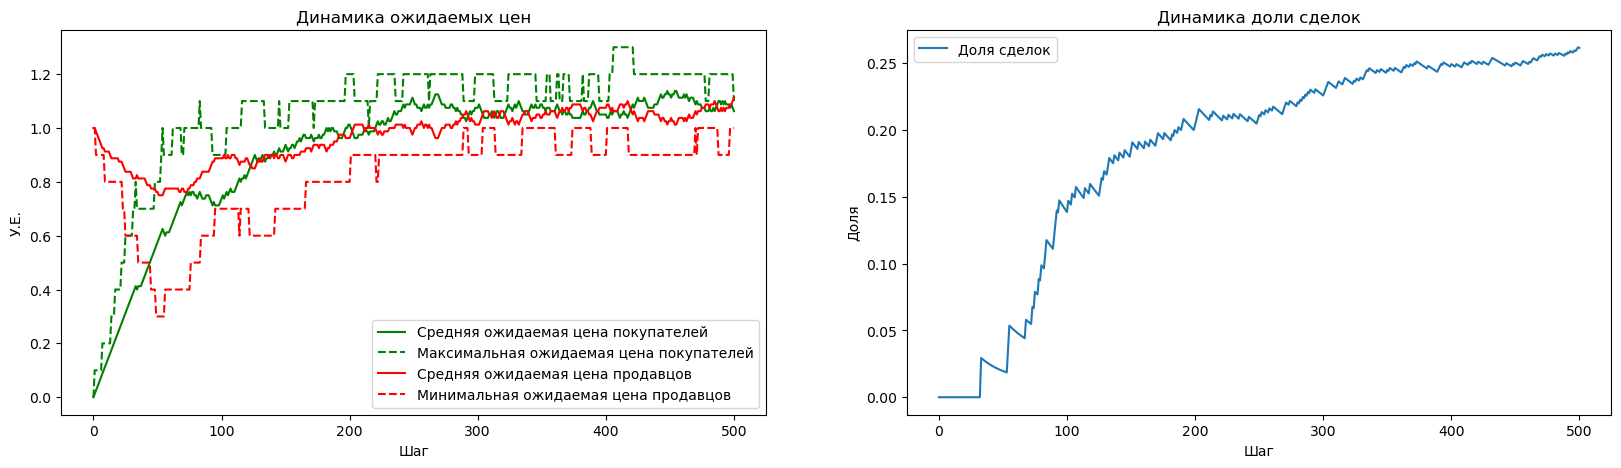

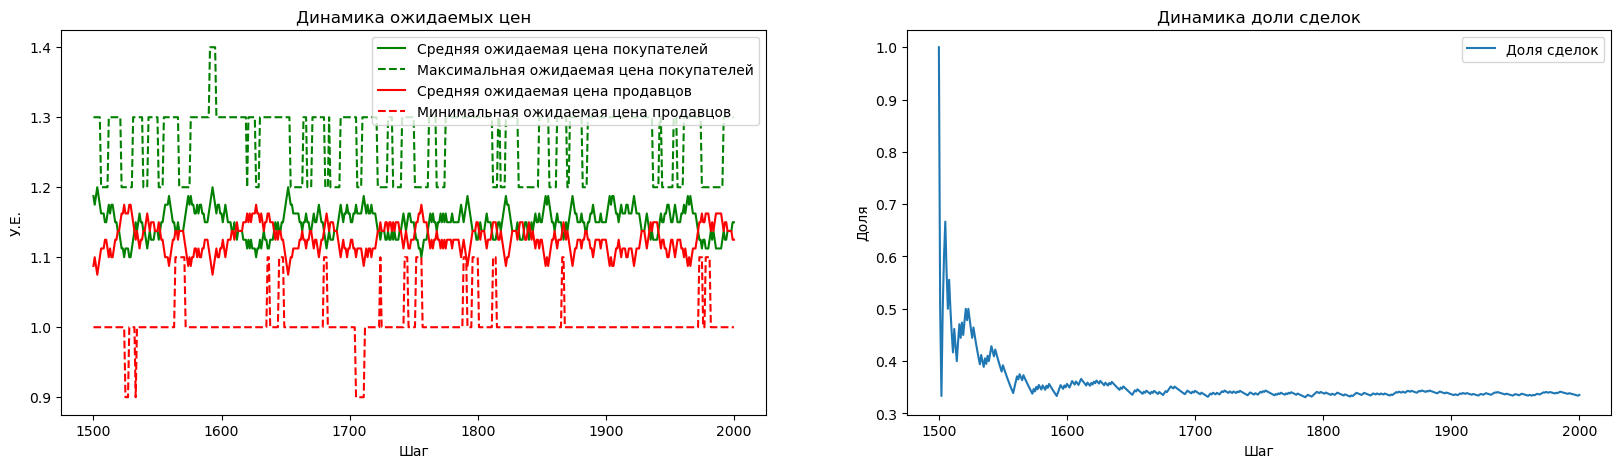

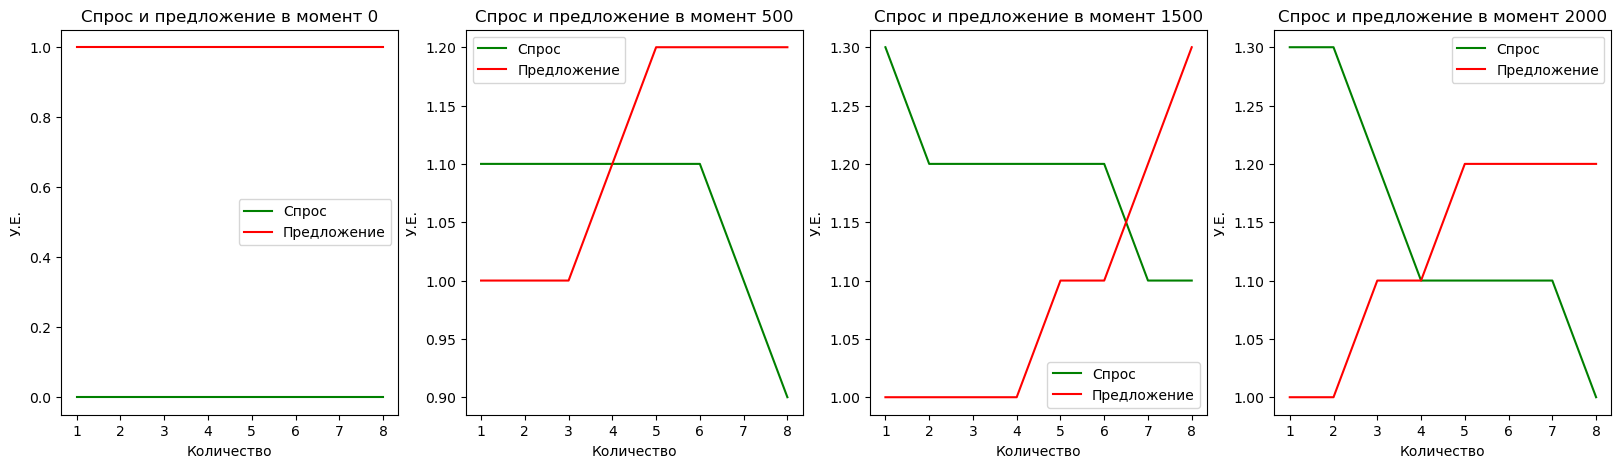

In [129]:
model_with_limits2 = Model_daily_limits(num_of_consumers=8, 
                                     num_of_sellers=8,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_delta=0.1,
                                     seller_min=0,
                                     seller_max=1,
                                     seller_delta=0.1,
                                     max_connections=10)

model_with_limits2.run(2000)
model_with_limits2.plot_dynamics(0, 2000)
model_with_limits2.plot_dynamics(0, 500)
model_with_limits2.plot_dynamics(1500, 2000)
model_with_limits2.plot_supply_and_demand([0, 500, 1500, 2000])

В ситуации, когда общее количество агентов примерно равно удвоенной длине дня, графики более похожи на привычные, уровень успешных сделок возрастает до 40%, однако также сохраняются(пусть и не так ярко выраженные) характерные заломы на графике доли успешных сделок, вызванные тем, что некоторые сделки не состоялись по причинам, не зависящем от цен товара.

100%|██████████| 2001/2001 [00:00<00:00, 86219.74it/s]


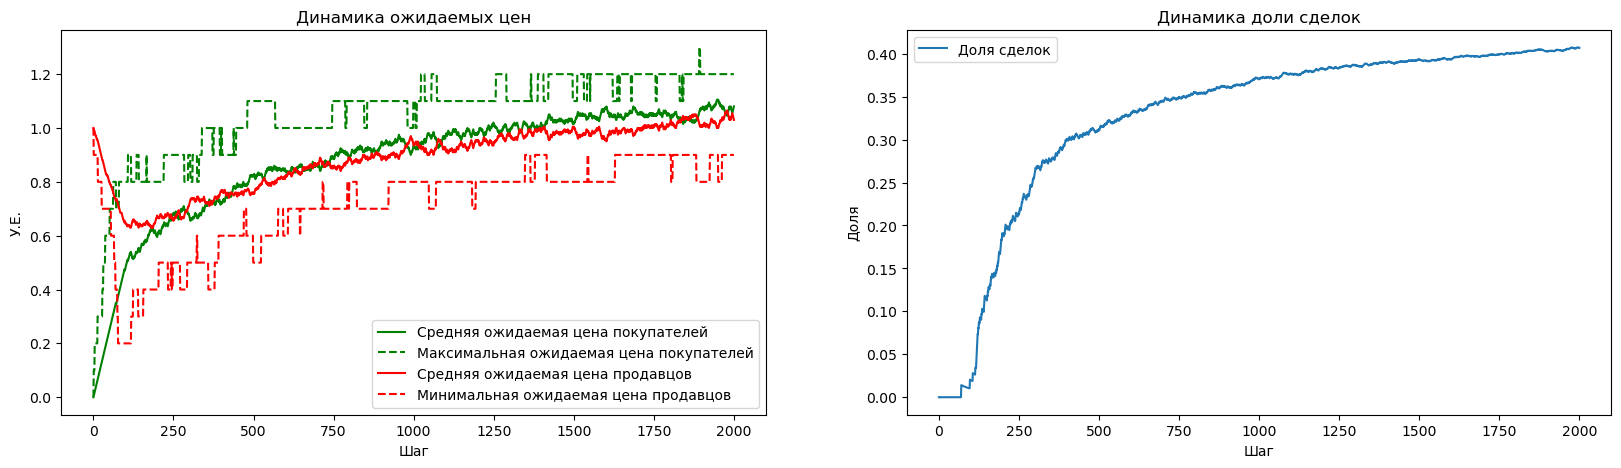

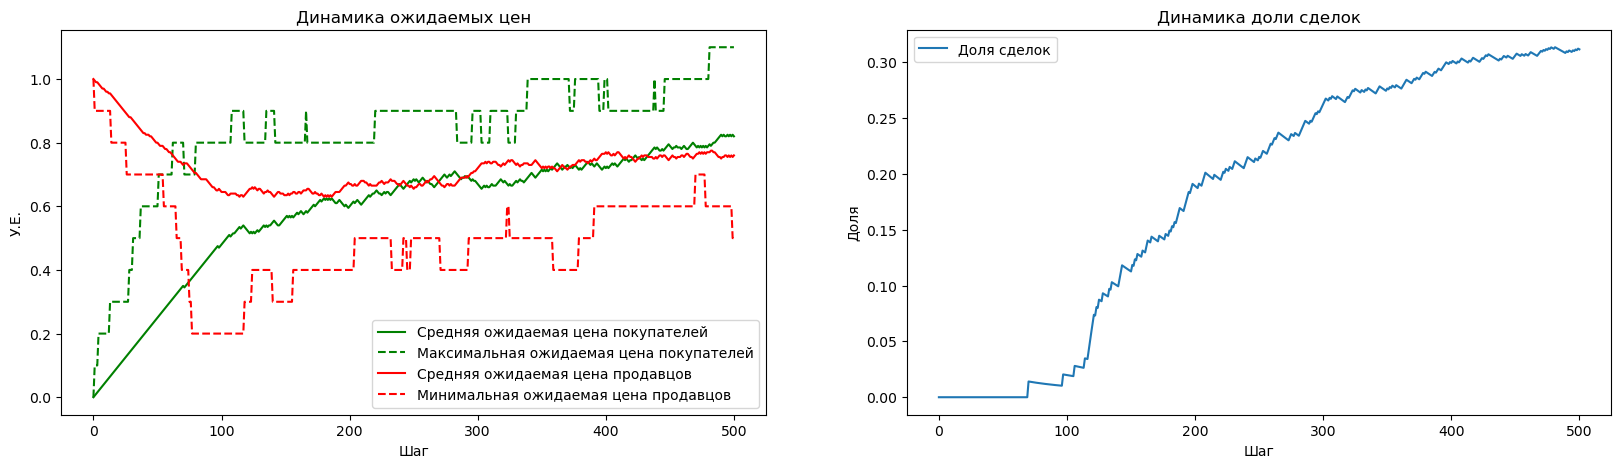

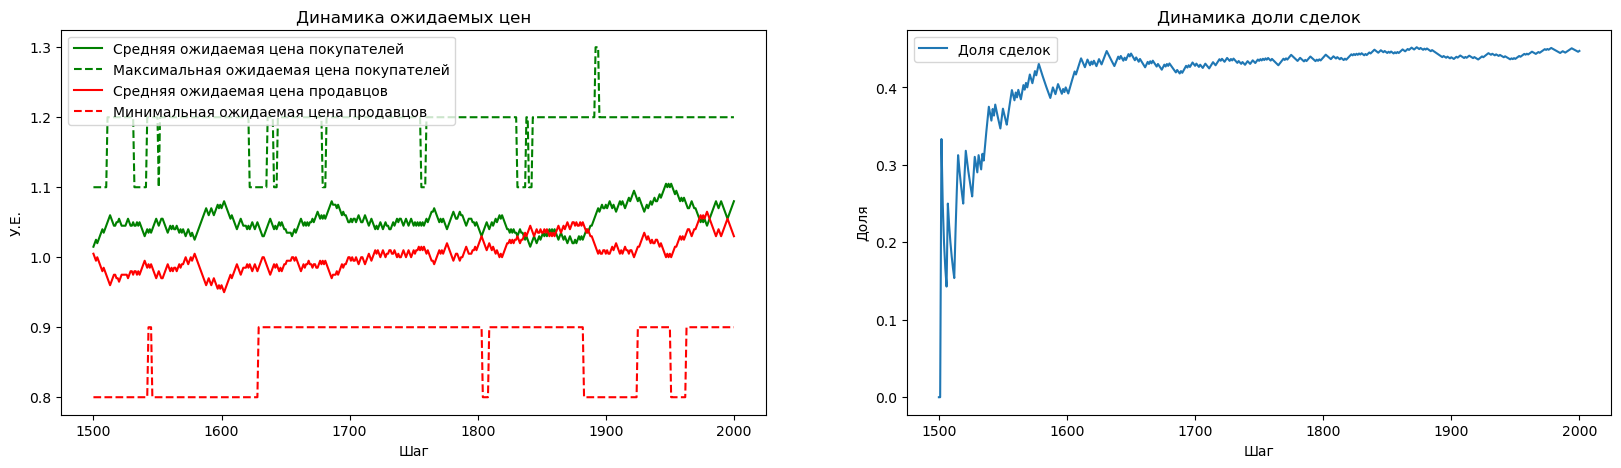

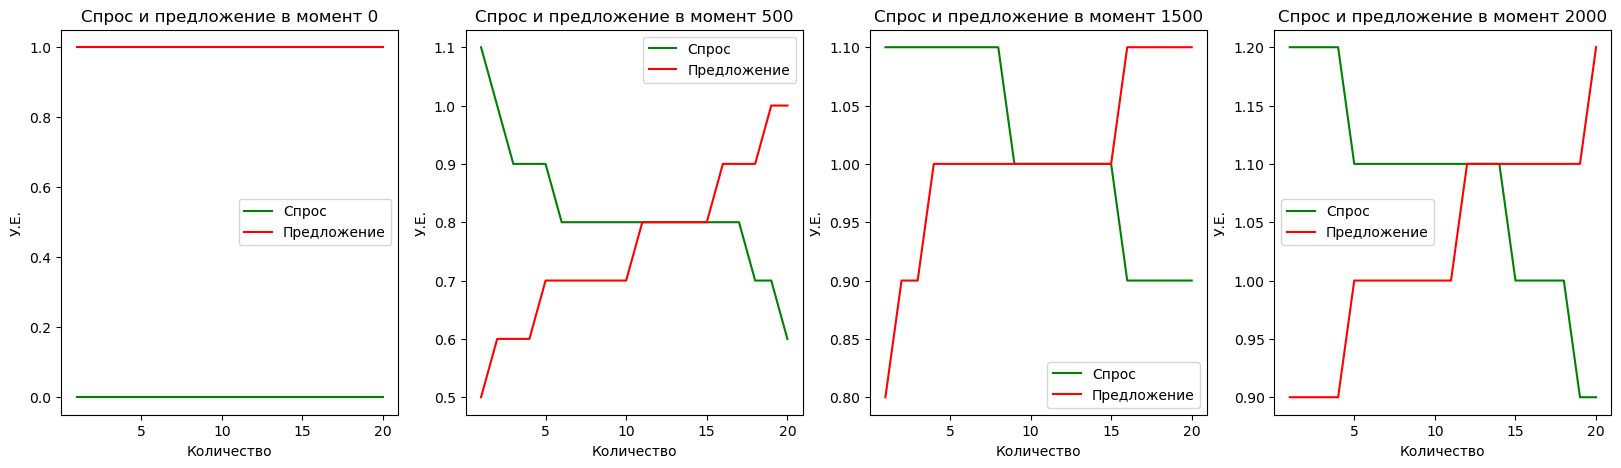

In [132]:
model_with_limits3 = Model_daily_limits(num_of_consumers=20, 
                                     num_of_sellers=20,
                                     consumer_min=3,
                                     consumer_max=4,
                                     consumer_delta=0.1,
                                     seller_min=0,
                                     seller_max=1,
                                     seller_delta=0.1,
                                     max_connections=5)

model_with_limits3.run(2000)
model_with_limits3.plot_dynamics(0, 2000)
model_with_limits3.plot_dynamics(0, 500)
model_with_limits3.plot_dynamics(1500, 2000)
model_with_limits3.plot_supply_and_demand([0, 500, 1500, 2000])

Как несложно было понять, если количество агентов значительно привосходит длину дня, то модифицированная модель ведет себя практически так же, как и базовая


## Задание 4 (4 балла)


Придумайте свою модификацию модели, в которой отражены другие черты реальных рынков.

<b><font color="red">!</font> Перед выполнением задания необходимо <a href="https://docs.google.com/forms/d/e/1FAIpQLSfOd3rBSQUAnE7VdCi_Yepvz5O3ZZhX8Zi2T5eYb7kFWw6ggg/viewform">согласовать</a> Вашу идею с преподавателем. Ваше предложение не должно совпадать с предыдущими модификациями или модификациями других студентов.
Все согласованные предложения от студентов будут отображаться в <a href="https://docs.google.com/spreadsheets/d/1Qu_Sr7ZSrm8tLLf33jEa06q7c9dS1EAUet9OlpnsY8U/edit?resourcekey#gid=1568177539">таблице</a>.</b>

* Продемонстрируйте и опишите работу модифицированной модели.
* По возможности сделайте ее визуализацию.
* Проинтерпретируйте результаты работы модели.


## Из уст в уста

У каждого покупателя добавляется определенное количество знакомых (не больше 10), при совершении успешной сделки с продавцом, покупатель может посоветовать одному из своих друзей этого продавца, в результате чего тот с большей вероятностью попробует совершить сделку не со случайным продавцом, а с уже проверенным его другом. 


In [113]:
class Consumer_with_friends(Consumer):
    def __init__(self, consumer_min, consumer_max, consumer_delta, num_of_consumers):
        super().__init__(consumer_min, consumer_max, consumer_delta)
        self.friends = []
        for _ in range(random.randint(0, min(10, num_of_consumers))):
            self.friends.append(random.randint(0, num_of_consumers - 1))
        self.adviced_seller = []
        

class Model_consumers_have_friends(Model):
    def __init__(self, num_of_consumers, num_of_sellers, consumer_min, consumer_max, consumer_delta, seller_min, seller_max, seller_delta):
        '''
            Конструктор класса.

            num_of_consumers -- количество покупателей
            num_of_sellers -- количество продавцов
            consumer_min -- минимальное возможное значение max_price для покупателей
            consumer_max -- максимально возможное значение max_price для покупателей
            consumer_delta -- шаг изменения expect_price для покупателей
            seller_min -- минимальное возможное значение min_price для продавцов
            seller_max -- максимально возможное значение min_price для продавцов
            seller_delta -- шаг изменения expect_price для продавцов

        '''
        self.num_of_consumers = num_of_consumers
        self.num_of_sellers = num_of_sellers

        # Список всех продавцов модели
        self.consumers = [Consumer_with_friends(consumer_min, consumer_max, consumer_delta, num_of_consumers) for _ in range(num_of_consumers)]

        # Список всех покупателей модели
        self.sellers = [Seller(seller_min, seller_max, seller_delta) for _ in range(num_of_sellers)]

        # Список списков. На позиции i находится список текущих значений expect_price для всех покупателей на шаге i.
        self.consumers_expect_price = []

        # Список списков. На позиции i находится список текущих значений expect_price для всех продавцов на шаге i.
        self.sellers_expect_price = []

        # Список результатов сделок. На позиции i находится словарь вида
        # {
        #     'consumer_id' : consumer_id,
        #     'seller_id' : seller_id
        #     'result' : result
        # }
        # где result = 1, если на i шаге была успешная сделка, иначе 0.
        self.deals_results = []

    def deal(self, consumer_id, seller_id):
        '''
            Моделирование сделки между покупателем с индексом consumer_id и продавцом с индексом seller_id

            consumer_id -- индекс покупателя в массиве self.consumers
            seller_id -- индекс продавца в массиве self.sellers
        '''

        # Сохраняем текущие значения expect_price покупателей
        self.consumers_expect_price.append([consumer.expect_price for consumer in self.consumers])

        # Сохраняем текущие значения expect_price продавцов
        self.sellers_expect_price.append([seller.expect_price for seller in self.sellers])

        if self.sellers[seller_id].expect_price <= self.consumers[consumer_id].expect_price:
            # Сделка состоялась

            # Записываем факт состоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 1
                })

            #Советуем продавца другу
            if (self.consumers[consumer_id].friends):
                friend = self.consumers[consumer_id].friends[random.randint(0, len(self.consumers[consumer_id].friends) - 1)]
                if self.sellers[seller_id].expect_price <= self.consumers[friend].expect_price:
                    # Сделка состоялась

                    # Записываем факт состоявшейся сделки
                    self.deals_results.append({
                        'consumer_id' : friend,
                        'seller_id' : seller_id,
                        'result' : 1
                        })

                    # Данный покупатель решает уменьшить у себя expect_price
                    self.consumers[friend].decrease_expect_price()

                    # Данный продавец решает увеличить у себя expect_price
                    self.sellers[seller_id].increase_expect_price()

                    #Друг и в будущем хочет торговать с этим продавцом
                    if (not self.consumers[friend].adviced_seller):
                        self.consumers[friend].adviced_seller.append(seller_id)
                    else:
                        self.consumers[friend].adviced_seller[0] = seller_id
                else:

                    # Данный покупатель решает увеличить у себя expect_price
                    self.sellers[seller_id].decrease_expect_price()

                    # Данный продавец решает уменьшить у себя expect_price
                    self.consumers[friend].increase_expect_price()
                
            # Данный покупатель решает уменьшить у себя expect_price
            self.consumers[consumer_id].decrease_expect_price()

            # Данный продавец решает увеличить у себя expect_price
            self.sellers[seller_id].increase_expect_price()

        else:
            # Сделка не состоялась

            # Записываем факт несостоявшейся сделки
            self.deals_results.append({
                'consumer_id' : consumer_id,
                'seller_id' : seller_id,
                'result' : 0
                })

            # Данный покупатель решает увеличить у себя expect_price
            self.sellers[seller_id].decrease_expect_price()

            # Данный продавец решает уменьшить у себя expect_price
            self.consumers[consumer_id].increase_expect_price()

    def run(self, num_of_steps):
        '''
            Запуск num_of_steps шагов модели
        '''
        for _ in trange(num_of_steps+1): # trange вместо range для визуализации прогресс-бара

            # Выбираем индекс покупателя случайным образом
            consumer_id = random.randrange(0, self.num_of_consumers)

            # Выбираем индекс продавца
            if (not self.consumers[consumer_id].adviced_seller):
                seller_id = random.randrange(0, self.num_of_sellers)
            else:   
                seller_id = self.consumers[consumer_id].adviced_seller[0]
                self.consumers[consumer_id].adviced_seller.pop(0)

            # Моделируем сделку
            self.deal(consumer_id, seller_id)

        

В модифицированной модели, у каждого потребителя теперь есть массив друзей, который заполняется случайно. Теперь при успешном совершении сделки покупатель может рассказать про это своему другу, который тоже попытается совершить сделку с тем же продавцом и при успехе в дальнейшем также будет стараться пытаться заключать сделки именно с ним. Запустим модель

100%|██████████| 1001/1001 [00:00<00:00, 244098.74it/s]


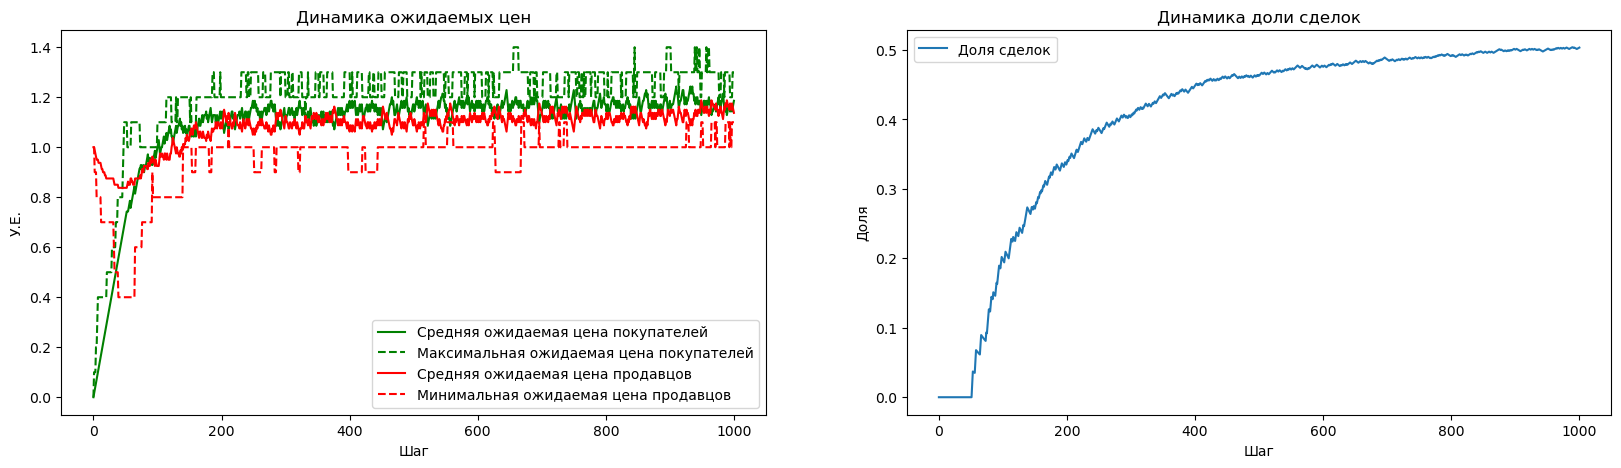

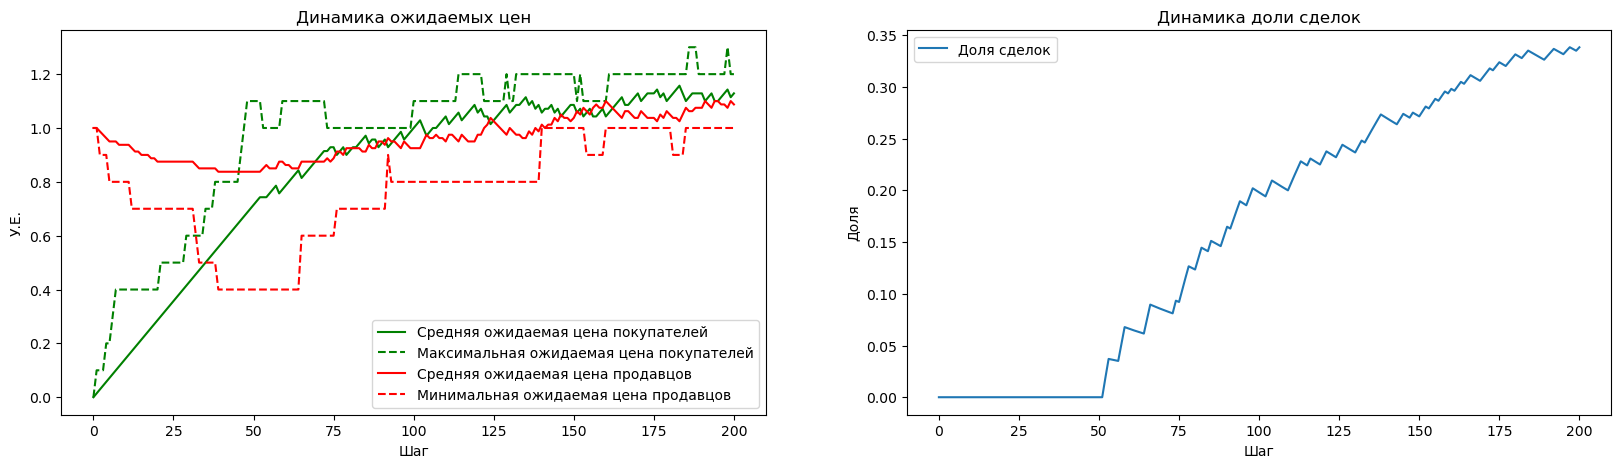

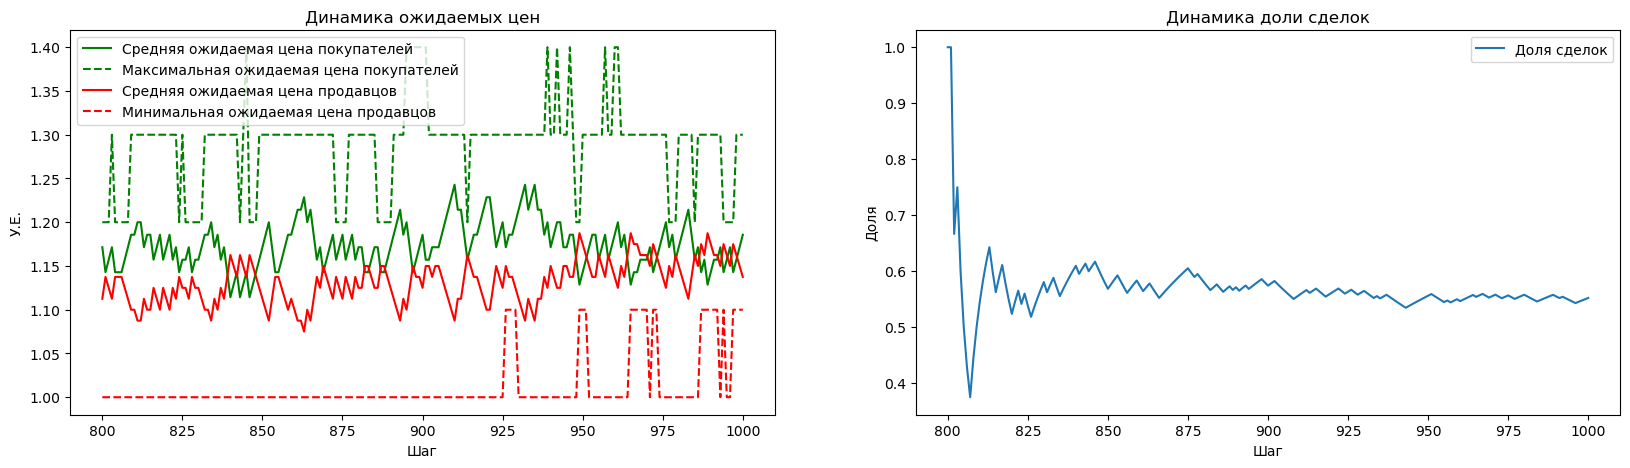

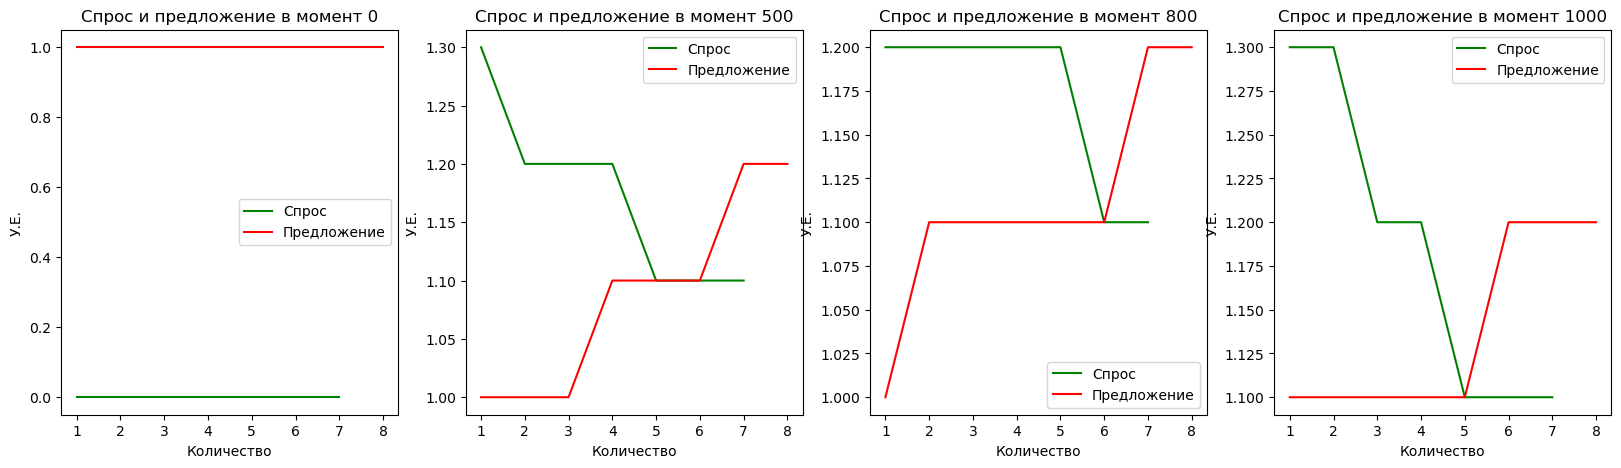

In [117]:
model_consumers_have_friends = Model_consumers_have_friends(num_of_consumers=7,
              num_of_sellers=8,
              consumer_min=3,
              consumer_max=4,
              consumer_delta=0.1,
              seller_min=0,
              seller_max=1,
              seller_delta=0.1)

model_consumers_have_friends.run(1000)
model_consumers_have_friends.plot_dynamics(0, 1000)
model_consumers_have_friends.plot_dynamics(0, 200)
model_consumers_have_friends.plot_dynamics(800, 1000)
model_consumers_have_friends.plot_supply_and_demand([0, 500, 800,   1000])

Как видно на графиках, как и в случае с базовой моделью, после определенного колличества тактов ожидаемые цены попадают в определенную окрестность и доля сделок выходит на относительно постоянный уровень. Результатом модификации модели является увелечение доли состоявшихся сделок, что можно объяснить тем, что при удачной изначальной сделке, покупатель советует этого производителя своему другу и происходит еще одна сделка, то есть по сути за 1 такт могут произойти 2 успешные сделки. При этом друг сохраняет продавца, если их сделка прошла успешно, и в будущем предпочтет торговать с ним, что тоже способствует повышению общей доли успешных сделок. При этом сохраняется существенная волатильность цен и доли успешных сделок, что можно объяснить достаточно большим влиянием случайных событий на работу модели

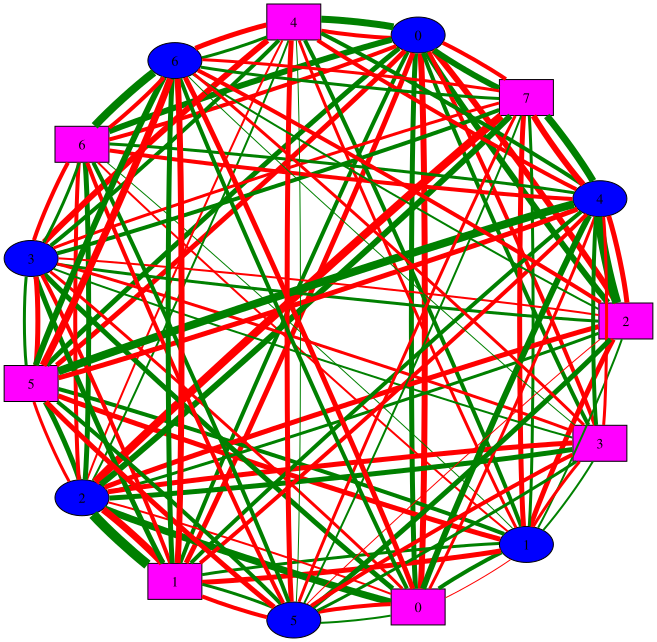

In [119]:
model_consumers_have_friends.plot_graph(0, 1000)

Так же можно отметить, что данная модификация модели сказалась на увеличении крепости связей между агентами, действительно т.к. при удачных сделках покупатели будут стремиться торговать с теми же производителями. (На этом запуске можно заметить довольно крепкую связь между агентами 1 и 2, 5 и 4)

100%|██████████| 1001/1001 [00:00<00:00, 293109.35it/s]


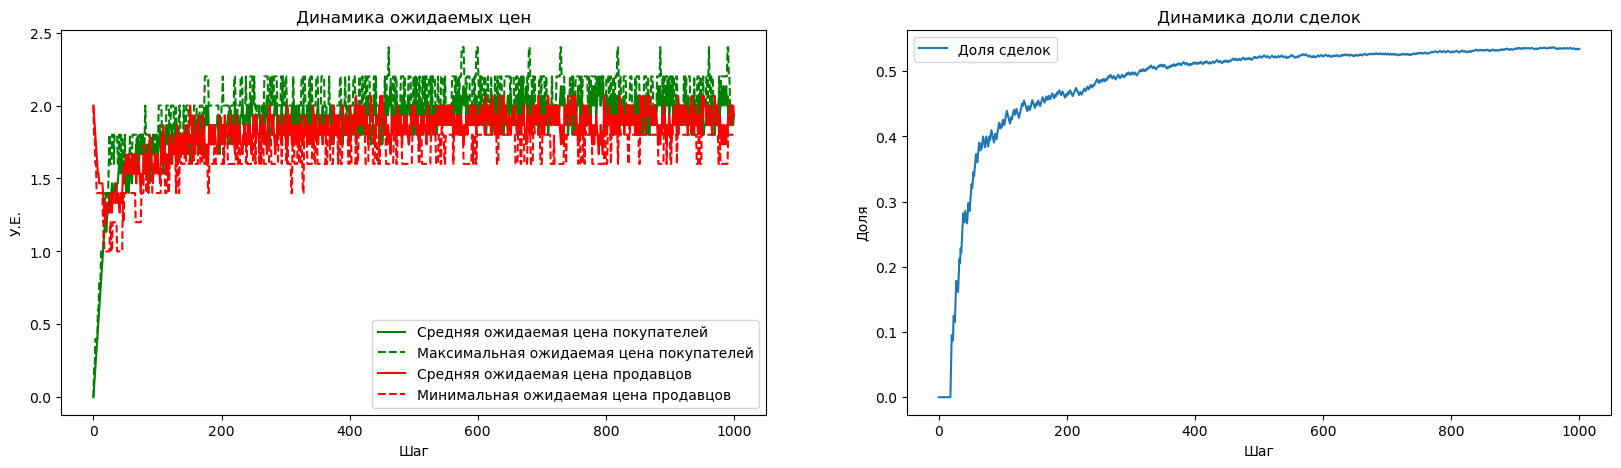

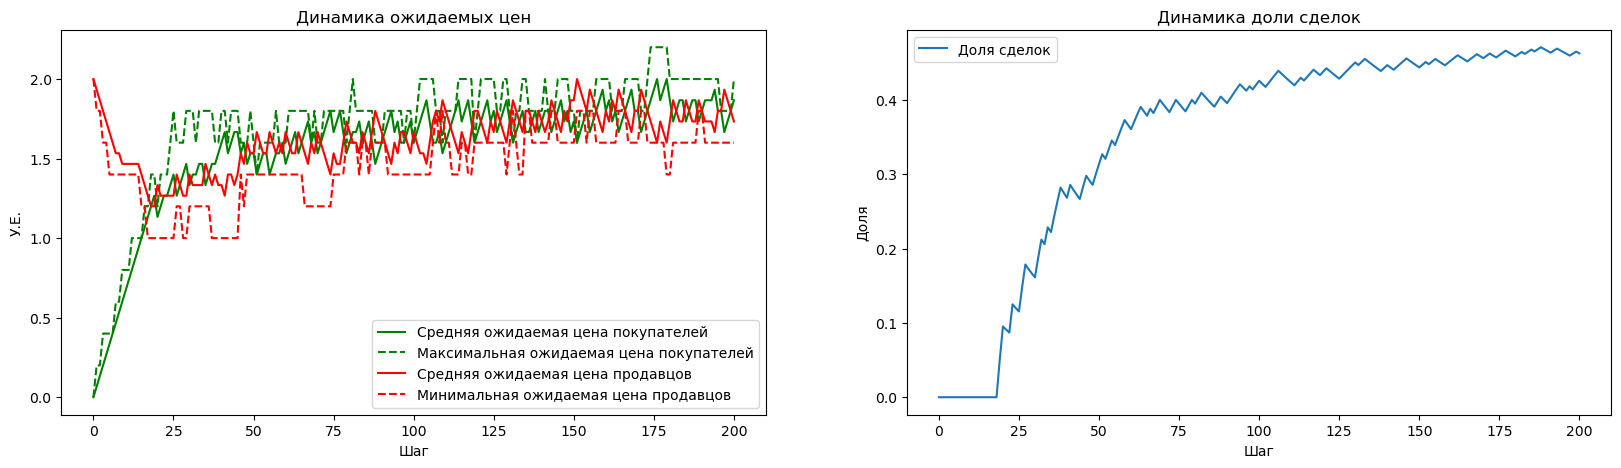

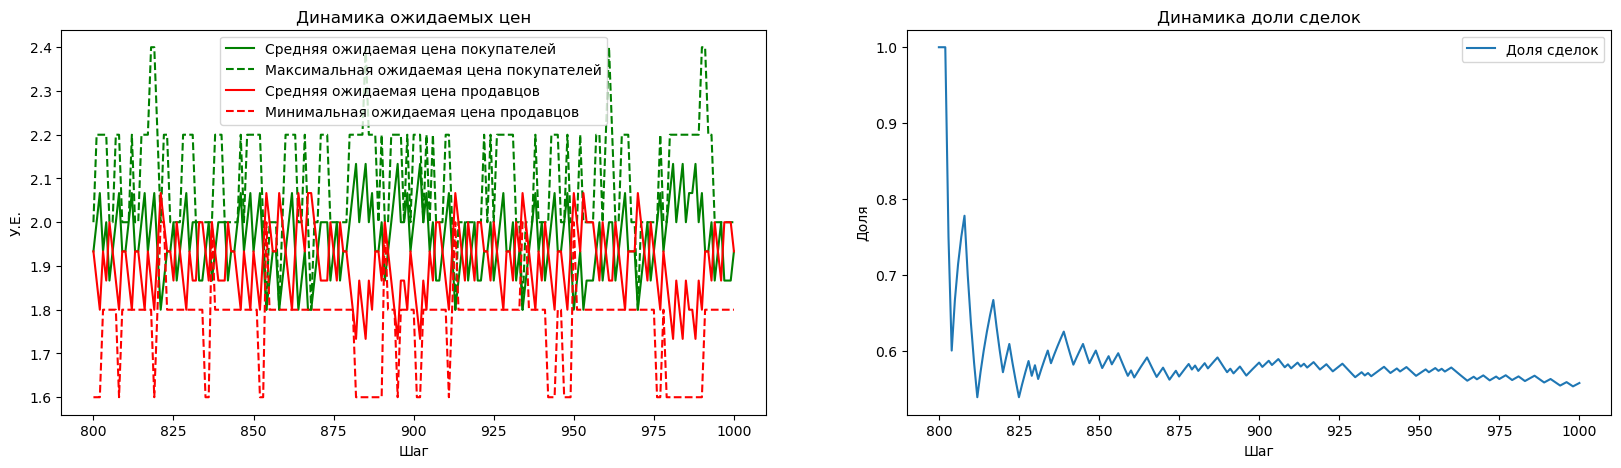

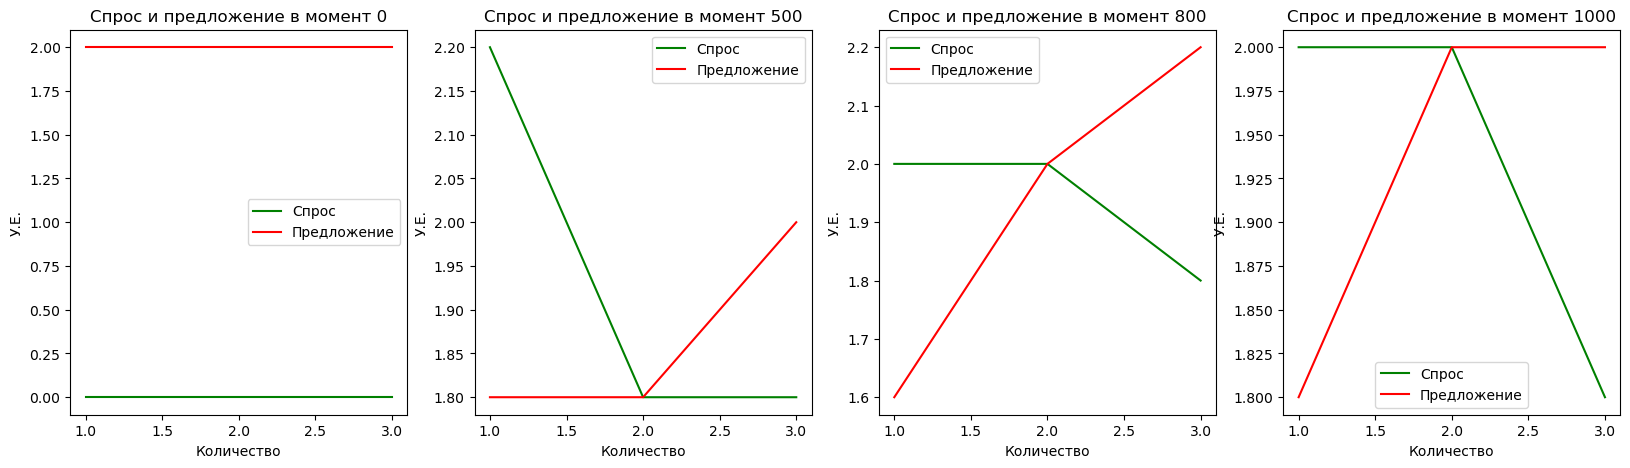

In [147]:
model_consumers_have_friends2 = Model_consumers_have_friends(num_of_consumers=3,
              num_of_sellers=3,
              consumer_min=2,
              consumer_max=5,
              consumer_delta=0.2,
              seller_min=0,
              seller_max=2,
              seller_delta=0.2)

model_consumers_have_friends2.run(1000)
model_consumers_have_friends2.plot_dynamics(0, 1000)
model_consumers_have_friends2.plot_dynamics(0, 200)
model_consumers_have_friends2.plot_dynamics(800, 1000)
model_consumers_have_friends2.plot_supply_and_demand([0, 500, 800, 1000])

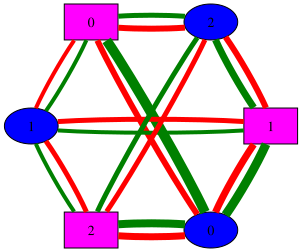

In [148]:
model_consumers_have_friends2.plot_graph(0, 1000)

Запустим нашу модель с другими параметрами, убедимся, что внешний вид графиков и графа остается схожим, значит и наши интерпритации тоже